# GraphGenerator on ZINC

This notebook demonstrates the two-stage `GraphGenerator`: first generate a new interpretation graph, then instantiate base molecules conditionally from nearby ZINC examples.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from collections import Counter

from nsppk import NSPPK
from sklearn.ensemble import RandomForestClassifier

from abstractgraph.display import display, display_decomposition_graph, display_mappings
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.edge_generator import EdgeGenerator
from abstractgraph_generative.graph_generator import GraphGenerator
from abstractgraph_ml.feasibility import FeasibilityEstimator, FeasibilityEstimatorFeatureCannotExist



/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [3]:
def draw(graph, decomposition_function, *, nbits=11, label_mode="operator_hash", size=(12, 6), n_elements_per_row=8):
    ag = graph_to_abstract_graph(
        graph,
        decomposition_function=decomposition_function,
        nbits=nbits,
        label_mode=label_mode,
    )
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag

---

In [4]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 3000
min_num_nodes = 30
max_num_nodes = 40

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")


dataset: zinc_250k
n_graphs: 3000
node_range: [30, 40]


In [5]:
label_mode = "histogram_values" #label_mode: str = "operator_hash" (default) or "histogram" or "histogram_values" for AbstractGraph node labeling.

nbits = 14

cycle_tree = add(
    compose(name("cycle"), cycle()),
    compose(name("tree"), tree()),
)
decomposition_function = compose(intersection_edges(), cycle_tree)

edge_vectorizer = NSPPK(radius=1, distance=3, connector=1, nbits=12, dense=True, parallel=True)
edge_graph_estimator = GraphEstimator(
    transformer=edge_vectorizer,
    estimator=RandomForestClassifier(
        n_estimators=80,
        random_state=0,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------
feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------

edge_generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=edge_graph_estimator,
    n_negative_per_positive=3,
    n_replicates=2,
    beam_size=3,
    max_restarts=2,
    fit_n_jobs=-1,
    fit_backend="loky",
    seed=0,
)

graph_vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, dense=True, parallel=True)
conditional_generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    base_cut_radius=0,
    interpretation_cut_radius=1,
    context_vectorizer=graph_vectorizer,
    n_jobs=1,
)

generator = GraphGenerator(
    edge_generator=edge_generator,
    conditional_generator=conditional_generator,
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    interpretation_neighbor_vectorizer=NSPPK(radius=1, distance=3, connector=1, nbits=12, dense=True, parallel=True),
    seed=None,
    debug=True,
    require_new_interpretation_graph=True,
    max_same_interpretation_retries=3,
)


In [6]:
generator.store(graphs)

In [7]:
n_samples = 4
n_instances_per_sample = 3
generated_graphs = generator.sample(
    n_samples=n_samples,
    n_interpretation_neighbors=10,
    n_conditional_neighbors=10,
    n_instances_per_sample=n_instances_per_sample,
    interpretation_edge_removal_size=0,  # 0 bypasses edge generation; 1 removes all interpretation edges before regrowth.
    random_state=None,
    conditional_generate_kwargs=dict(
        random_state=None,
        max_backtracks=2000,
        max_attempts_per_sample=6,
        require_signature_coverage=True,
    ),
)

generated_groups = [
    generated_graphs[i : i + n_instances_per_sample]
    for i in range(0, len(generated_graphs), n_instances_per_sample)
]

print(f"generated molecules: {len(generated_graphs)}")
print("attempted seed indices:", generator.last_sampled_indices_)
print("successful seed indices:", generator.last_successful_sampled_indices_)
print("successful interpretation targets:", len(generator.last_generated_interpretation_graphs_))
if not generated_graphs:
    print("No molecules generated; inspect warnings and try a larger neighborhood or dataset slice.")


[DEBUG] event=fit_dictionaries
[DEBUG]   bucket_keys=51
[DEBUG]   components=74
[DEBUG]   interpretation_pool=10
[DEBUG]   inv_freq_keys=71
[DEBUG]   inv_keys=71
[DEBUG]   skipped_missing_anchor_components=0
[DEBUG] event=fit_distributions_index
[DEBUG]   bucket_size=min/mean/max=(1/1.45/6)
[DEBUG]   inv_members=min/mean/max=(1/1.39/6)
[DEBUG] event=fit_distributions_components
[DEBUG]   anchors_per_port=min/mean/max=(1/1.16/2)
[DEBUG]   component_degree=min/mean/max=(1/1.73/4)
[DEBUG]   ports_per_component=min/mean/max=(1/1.73/4)
[DEBUG] event=fit_anchors
[DEBUG]   inv_multiplicity_hist={1: 59, 2: 12}
[DEBUG]   unique_anchor_types=2
[DEBUG] event=fit_anchor_hist
[DEBUG]   anchors_per_base_subgraph_hist={1: 23, 2: 36, 3: 10, 4: 2, 5: 3}
[DEBUG] event=fit_top_buckets
[DEBUG]   top_buckets=
[DEBUG]     [{'key': (177694, 1), 'size': 6}, {'key': (371011, 2), 'size': 5}, {'key': (110962, 2), 'size': 5},
[DEBUG]      {'key': (495697, 1), 'size': 2}, {'key': (389136, 1), 'size': 2}, {'key': (

/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/conditional.py:2775: RuntimeWarning: generate requested n_samples=3 but produced 0 after 72 attempts (budget=72).
  warnings.warn(
/var/folders/2n/3z7x0v752fv_ftkm1nktf9qr0000gp/T/ipykernel_35349/3970206498.py:3: RuntimeWarning: Conditional stage generated no graphs matching the generated interpretation graph; skipping seed.
  generated_graphs = generator.sample(


[DEBUG] event=fit_dictionaries
[DEBUG]   bucket_keys=48
[DEBUG]   components=86
[DEBUG]   interpretation_pool=10
[DEBUG]   inv_freq_keys=71
[DEBUG]   inv_keys=71
[DEBUG]   skipped_missing_anchor_components=0
[DEBUG] event=fit_distributions_index
[DEBUG]   bucket_size=min/mean/max=(1/1.79/6)
[DEBUG]   inv_members=min/mean/max=(1/1.65/6)
[DEBUG] event=fit_distributions_components
[DEBUG]   anchors_per_port=min/mean/max=(1/1.09/2)
[DEBUG]   component_degree=min/mean/max=(1/1.77/3)
[DEBUG]   ports_per_component=min/mean/max=(1/1.77/3)
[DEBUG] event=fit_anchors
[DEBUG]   inv_multiplicity_hist={1: 64, 2: 7}
[DEBUG]   unique_anchor_types=2
[DEBUG] event=fit_anchor_hist
[DEBUG]   anchors_per_base_subgraph_hist={1: 30, 2: 42, 3: 5, 4: 8, 5: 1}
[DEBUG] event=fit_top_buckets
[DEBUG]   top_buckets=
[DEBUG]     [{'key': (519121, 2), 'size': 6}, {'key': (507215, 3), 'size': 5}, {'key': (94258, 1), 'size': 5},
[DEBUG]      {'key': (44201, 2), 'size': 5}, {'key': (18762, 1), 'size': 5}, {'key': (43978

/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/conditional.py:2775: RuntimeWarning: generate requested n_samples=3 but produced 0 after 72 attempts (budget=72).
  warnings.warn(
/var/folders/2n/3z7x0v752fv_ftkm1nktf9qr0000gp/T/ipykernel_35349/3970206498.py:3: RuntimeWarning: Conditional stage generated no graphs matching the generated interpretation graph; skipping seed.
  generated_graphs = generator.sample(


[DEBUG] event=fit_dictionaries
[DEBUG]   bucket_keys=61
[DEBUG]   components=81
[DEBUG]   interpretation_pool=10
[DEBUG]   inv_freq_keys=83
[DEBUG]   inv_keys=83
[DEBUG]   skipped_missing_anchor_components=0
[DEBUG] event=fit_distributions_index
[DEBUG]   bucket_size=min/mean/max=(1/1.33/5)
[DEBUG]   inv_members=min/mean/max=(1/1.25/5)
[DEBUG] event=fit_distributions_components
[DEBUG]   anchors_per_port=min/mean/max=(1/1.04/2)
[DEBUG]   component_degree=min/mean/max=(1/1.75/3)
[DEBUG]   ports_per_component=min/mean/max=(1/1.75/3)
[DEBUG] event=fit_anchors
[DEBUG]   inv_multiplicity_hist={1: 77, 2: 6}
[DEBUG]   unique_anchor_types=2
[DEBUG] event=fit_anchor_hist
[DEBUG]   anchors_per_base_subgraph_hist={1: 21, 2: 55, 3: 3, 4: 2}
[DEBUG] event=fit_top_buckets
[DEBUG]   top_buckets=
[DEBUG]     [{'key': (369876, 2), 'size': 5}, {'key': (356225, 2), 'size': 5}, {'key': (18762, 1), 'size': 4},
[DEBUG]      {'key': (519121, 2), 'size': 2}, {'key': (389136, 1), 'size': 2}, {'key': (388274, 2

...

[DEBUG] event=fit_dictionaries
[DEBUG]   bucket_keys=48
[DEBUG]   components=60
[DEBUG]   interpretation_pool=10
[DEBUG]   inv_freq_keys=87
[DEBUG]   inv_keys=87
[DEBUG]   skipped_missing_anchor_components=0
[DEBUG] event=fit_distributions_index
[DEBUG]   bucket_size=min/mean/max=(1/1.25/3)
[DEBUG]   inv_members=min/mean/max=(1/1.21/3)
[DEBUG] event=fit_distributions_components
[DEBUG]   anchors_per_port=min/mean/max=(1/1.36/10)
[DEBUG]   component_degree=min/mean/max=(1/1.67/3)
[DEBUG]   ports_per_component=min/mean/max=(1/1.67/3)
[DEBUG] event=fit_anchors
[DEBUG]   inv_multiplicity_hist={1: 63, 2: 16, 3: 2, 4: 2, 5: 2, 6: 2}
[DEBUG]   unique_anchor_types=3
[DEBUG] event=fit_anchor_hist
[DEBUG]   anchors_per_base_subgraph_hist={1: 20, 2: 24, 3: 10, 4: 4, 10: 1, 12: 1}
[DEBUG] event=fit_top_buckets
[DEBUG]   top_buckets=
[DEBUG]     [{'key': (94258, 1), 'size': 3}, {'key': (450852, 1), 'size': 2}, {'key': (438895, 2), 'size': 2},
[DEBUG]      {'key': (383463, 2), 'size': 2}, {'key': (2

/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/conditional.py:2775: RuntimeWarning: generate requested n_samples=3 but produced 0 after 72 attempts (budget=72).
  warnings.warn(
/var/folders/2n/3z7x0v752fv_ftkm1nktf9qr0000gp/T/ipykernel_35349/3970206498.py:3: RuntimeWarning: Conditional stage generated no graphs matching the generated interpretation graph; skipping seed.
  generated_graphs = generator.sample(


[DEBUG] event=fit_dictionaries
[DEBUG]   bucket_keys=45
[DEBUG]   components=69
[DEBUG]   interpretation_pool=10
[DEBUG]   inv_freq_keys=57
[DEBUG]   inv_keys=57
[DEBUG]   skipped_missing_anchor_components=0
[DEBUG] event=fit_distributions_index
[DEBUG]   bucket_size=min/mean/max=(1/1.53/10)
[DEBUG]   inv_members=min/mean/max=(1/1.65/10)
[DEBUG] event=fit_distributions_components
[DEBUG]   anchors_per_port=min/mean/max=(1/1.05/2)
[DEBUG]   component_degree=min/mean/max=(1/1.71/3)
[DEBUG]   ports_per_component=min/mean/max=(1/1.71/3)
[DEBUG] event=fit_anchors
[DEBUG]   inv_multiplicity_hist={1: 52, 2: 5}
[DEBUG]   unique_anchor_types=2
[DEBUG] event=fit_anchor_hist
[DEBUG]   anchors_per_base_subgraph_hist={1: 18, 2: 47, 3: 4}
[DEBUG] event=fit_top_buckets
[DEBUG]   top_buckets=
[DEBUG]     [{'key': (516876, 2), 'size': 10}, {'key': (389136, 1), 'size': 4}, {'key': (291049, 1), 'size': 4},
[DEBUG]      {'key': (379406, 2), 'size': 3}, {'key': (323722, 2), 'size': 3}, {'key': (38690, 2), 

/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/conditional.py:2775: RuntimeWarning: generate requested n_samples=3 but produced 0 after 72 attempts (budget=72).
  warnings.warn(
/var/folders/2n/3z7x0v752fv_ftkm1nktf9qr0000gp/T/ipykernel_35349/3970206498.py:3: RuntimeWarning: Conditional stage generated no graphs matching the generated interpretation graph; skipping seed.
  generated_graphs = generator.sample(


[DEBUG] event=fit_dictionaries
[DEBUG]   bucket_keys=49
[DEBUG]   components=67
[DEBUG]   interpretation_pool=10
[DEBUG]   inv_freq_keys=69
[DEBUG]   inv_keys=69
[DEBUG]   skipped_missing_anchor_components=0
[DEBUG] event=fit_distributions_index
[DEBUG]   bucket_size=min/mean/max=(1/1.37/5)
[DEBUG]   inv_members=min/mean/max=(1/1.32/5)
[DEBUG] event=fit_distributions_components
[DEBUG]   anchors_per_port=min/mean/max=(1/1.16/2)
[DEBUG]   component_degree=min/mean/max=(1/1.70/3)
[DEBUG]   ports_per_component=min/mean/max=(1/1.70/3)
[DEBUG] event=fit_anchors
[DEBUG]   inv_multiplicity_hist={1: 55, 2: 14}
[DEBUG]   unique_anchor_types=2
[DEBUG] event=fit_anchor_hist
[DEBUG]   anchors_per_base_subgraph_hist={1: 23, 2: 27, 3: 13, 4: 4}
[DEBUG] event=fit_top_buckets
[DEBUG]   top_buckets=
[DEBUG]     [{'key': (291049, 1), 'size': 5}, {'key': (119171, 1), 'size': 4}, {'key': (27260, 1), 'size': 4},
[DEBUG]      {'key': (167865, 1), 'size': 3}, {'key': (474681, 3), 'size': 2}, {'key': (381362,

seed molecule


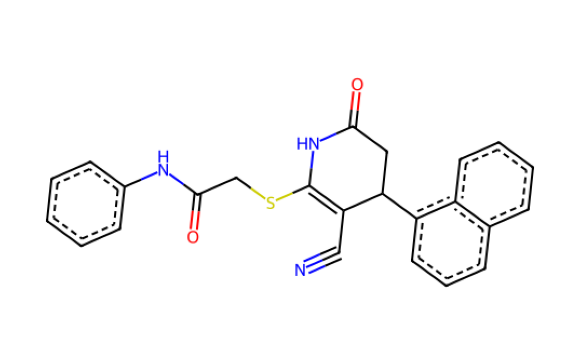

generated molecule instances (3)


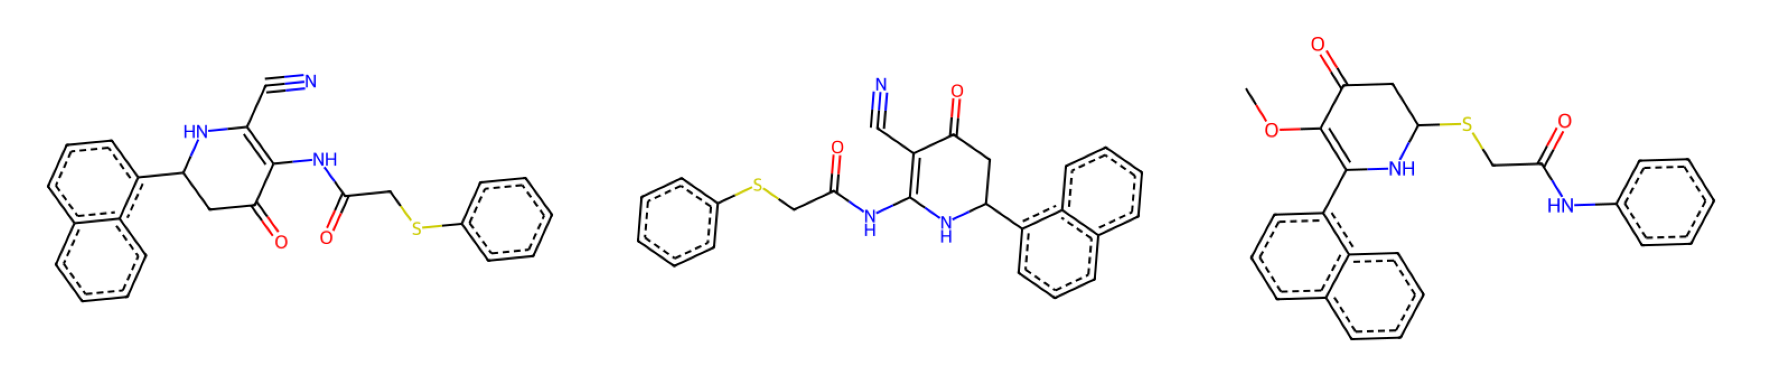

seed molecule


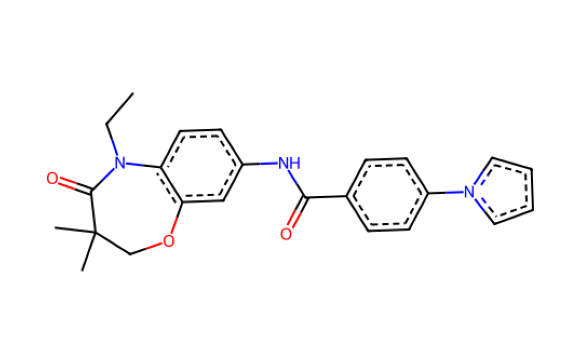

generated molecule instances (3)


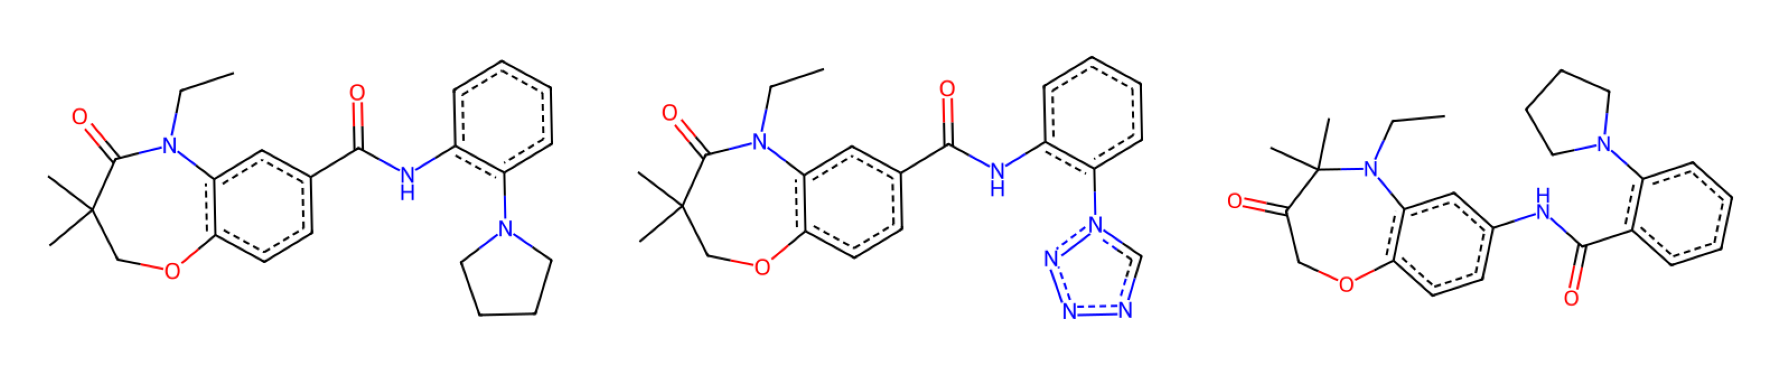

seed molecule


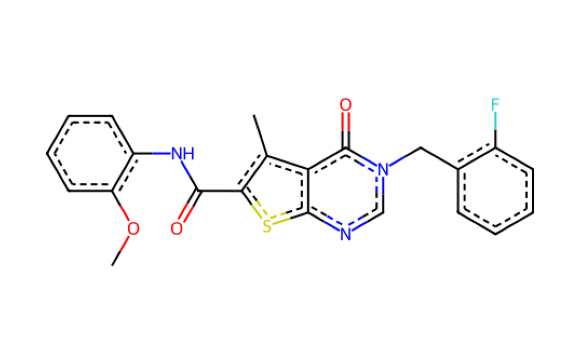

generated molecule instances (3)


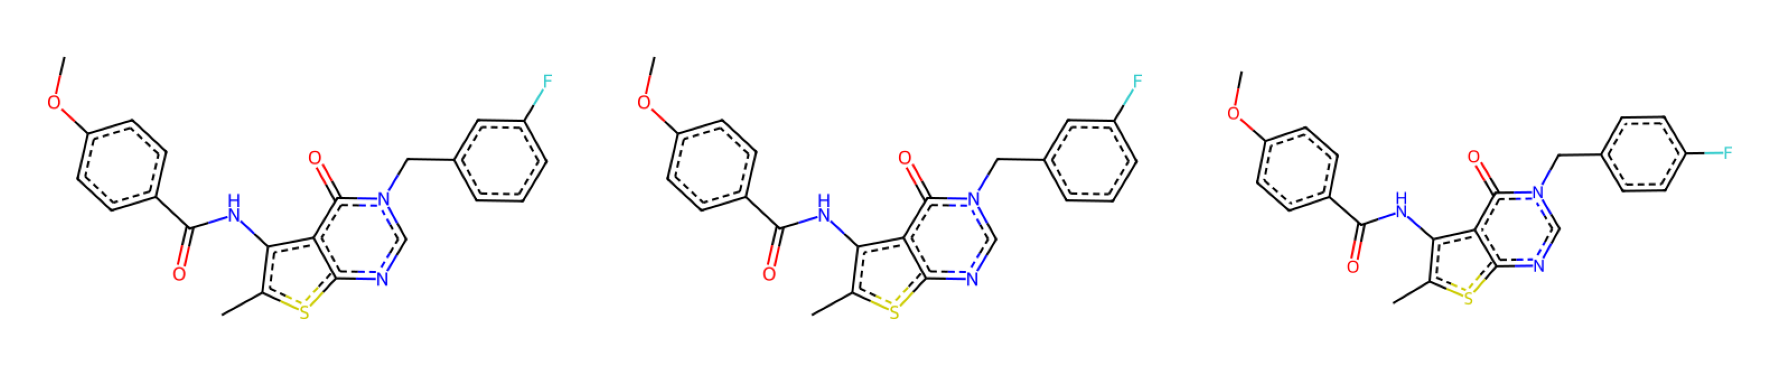

seed molecule


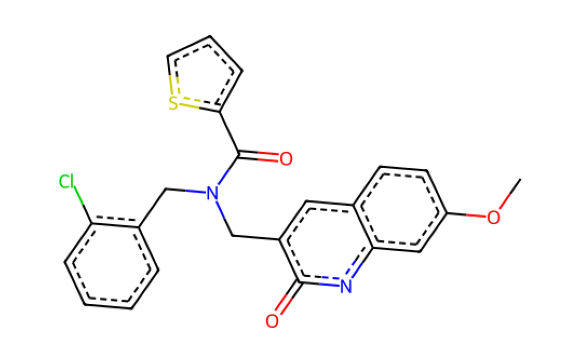

generated molecule instances (3)


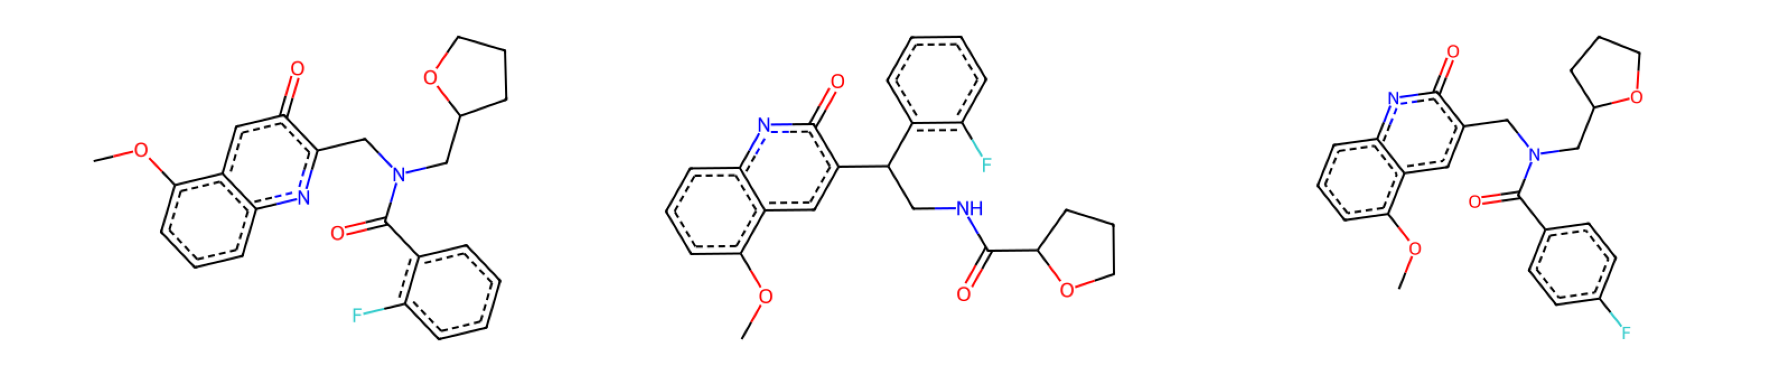

In [8]:
if not generated_graphs:
    print("No generated molecules to display.")
else:
    for sample_idx, (seed_idx,seed_graph,seed_interpretation_graph,generated_interpretation_graph,generated_instances,) in enumerate(zip(generator.last_successful_sampled_indices_,generator.last_seed_graphs_,generator.last_seed_interpretation_graphs_,generator.last_generated_interpretation_graphs_,generated_groups,)):
        print("seed molecule")
        display_graphs([seed_graph], n_graphs_per_line=1)
        
        print(f"generated molecule instances ({len(generated_instances)})")
        display_graphs(generated_instances, n_graphs_per_line=n_instances_per_sample)

sample 0 | seed index 2182
seed molecule


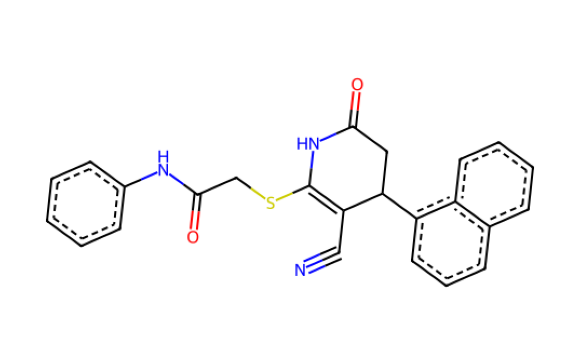

seed interpretation graph
generated interpretation graph
generated molecule instances (3)


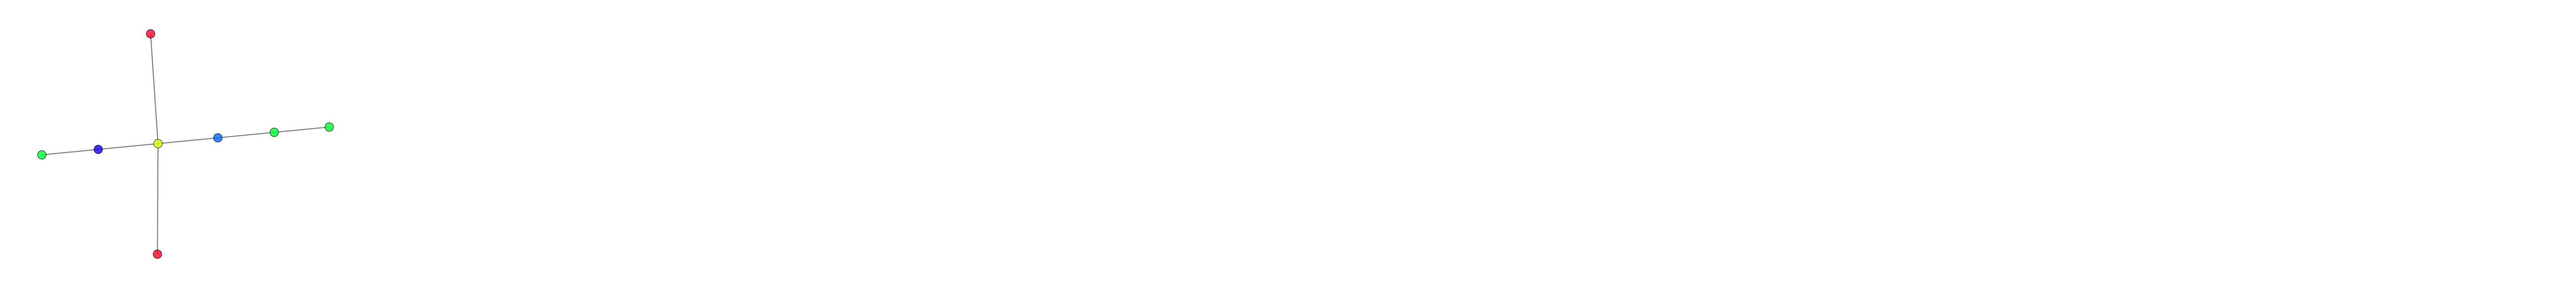

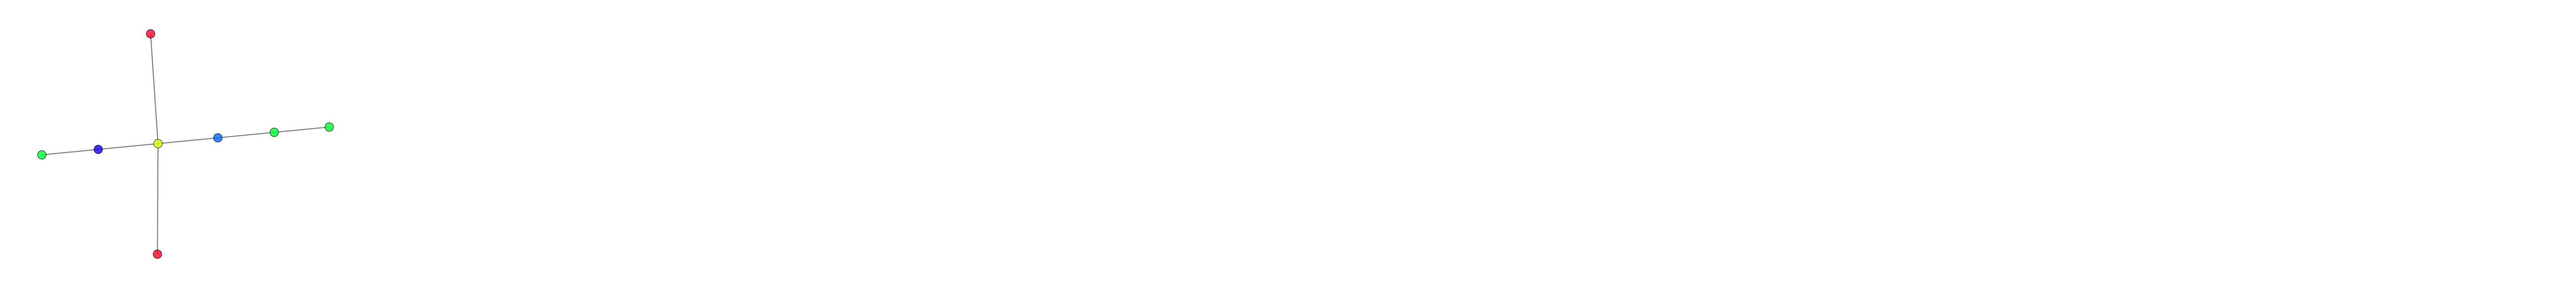

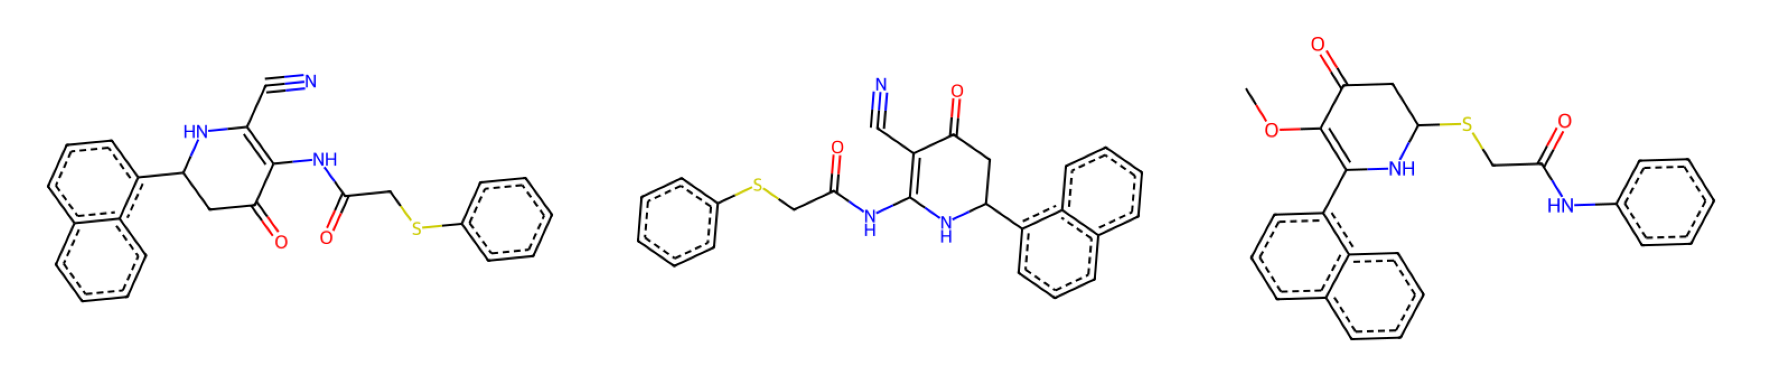

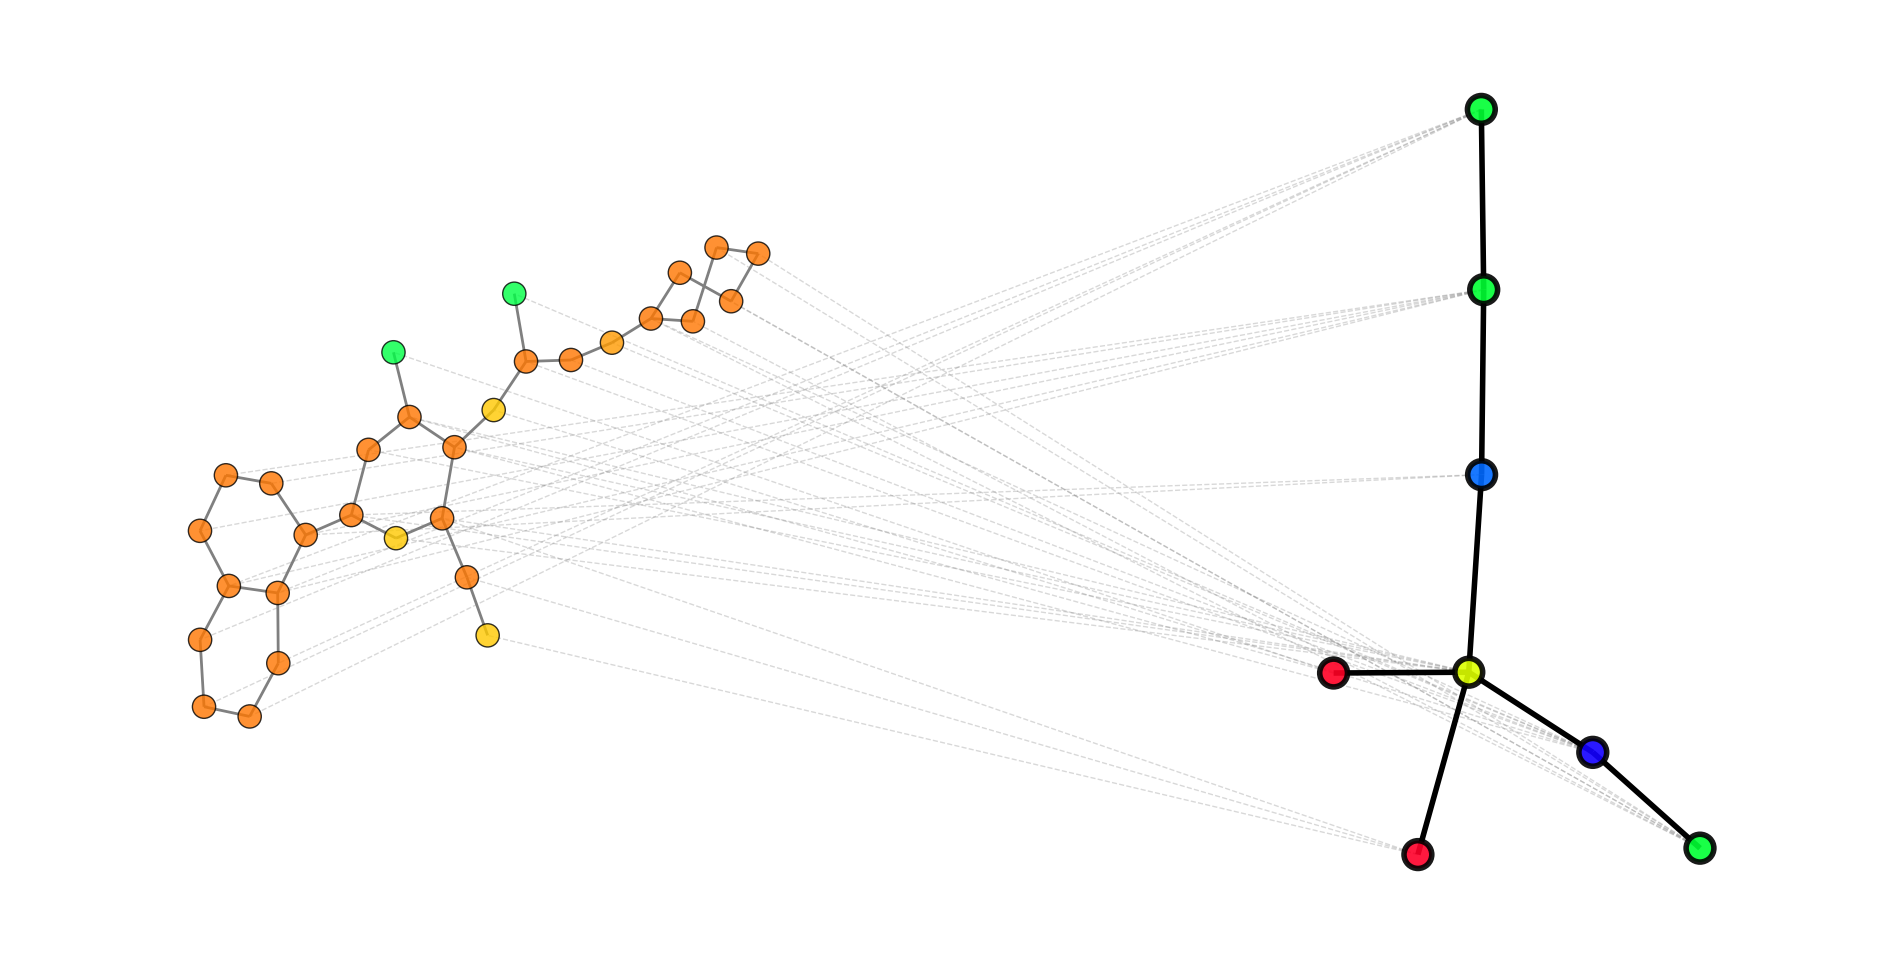

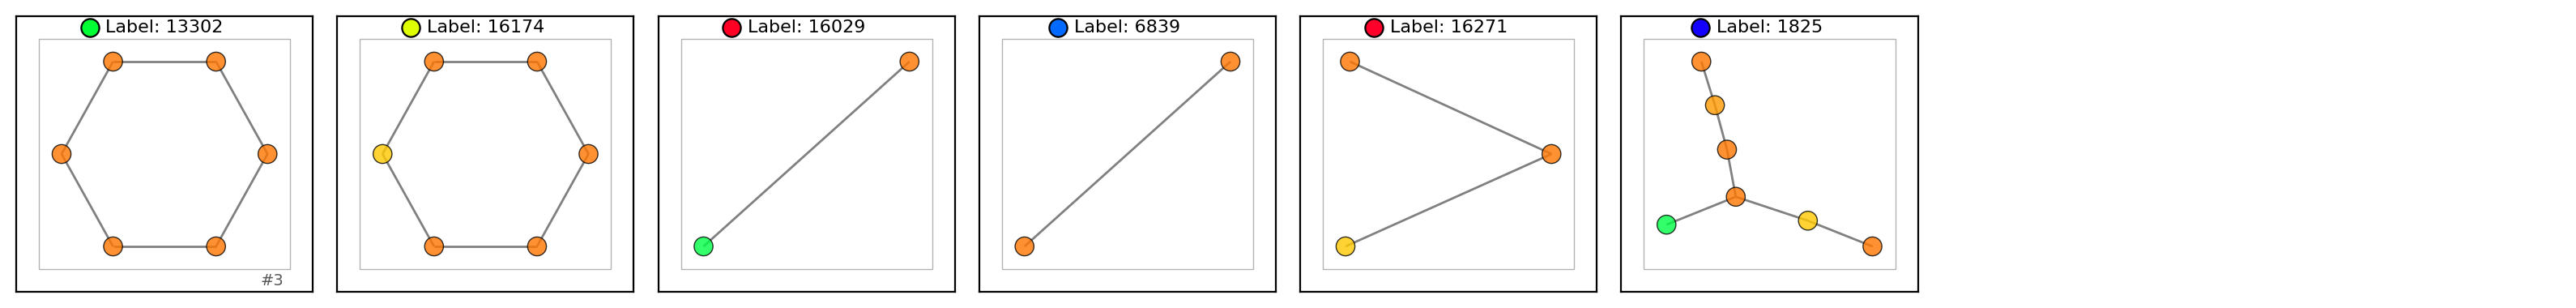

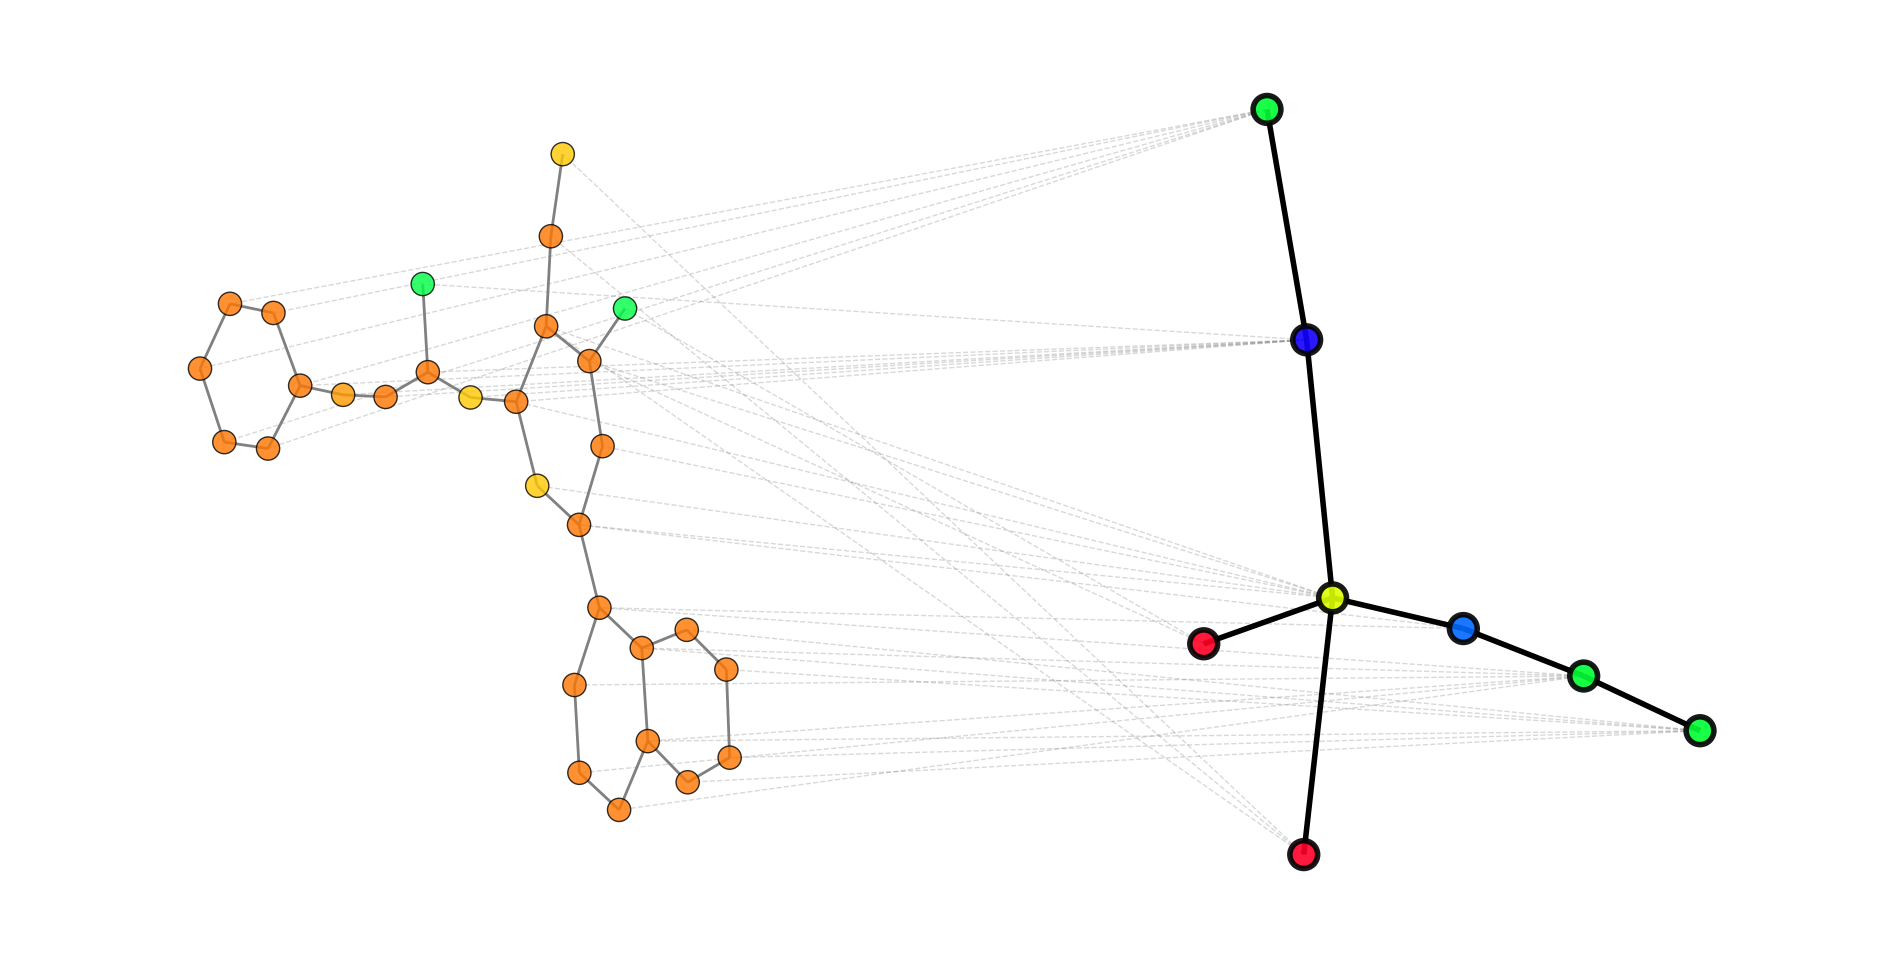

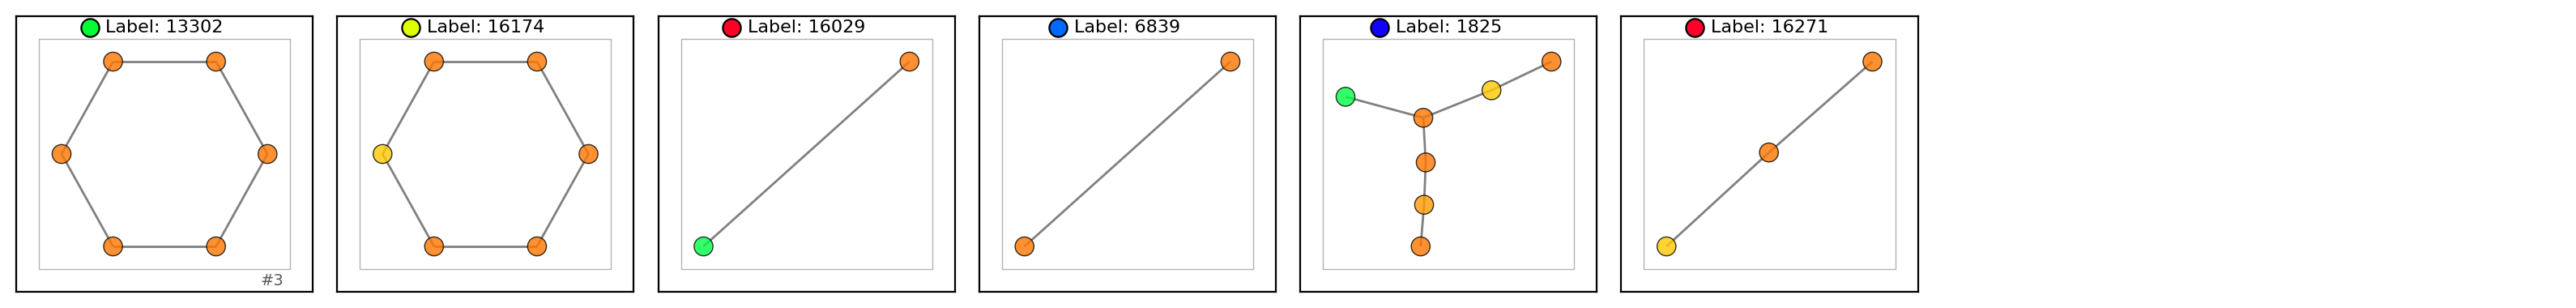

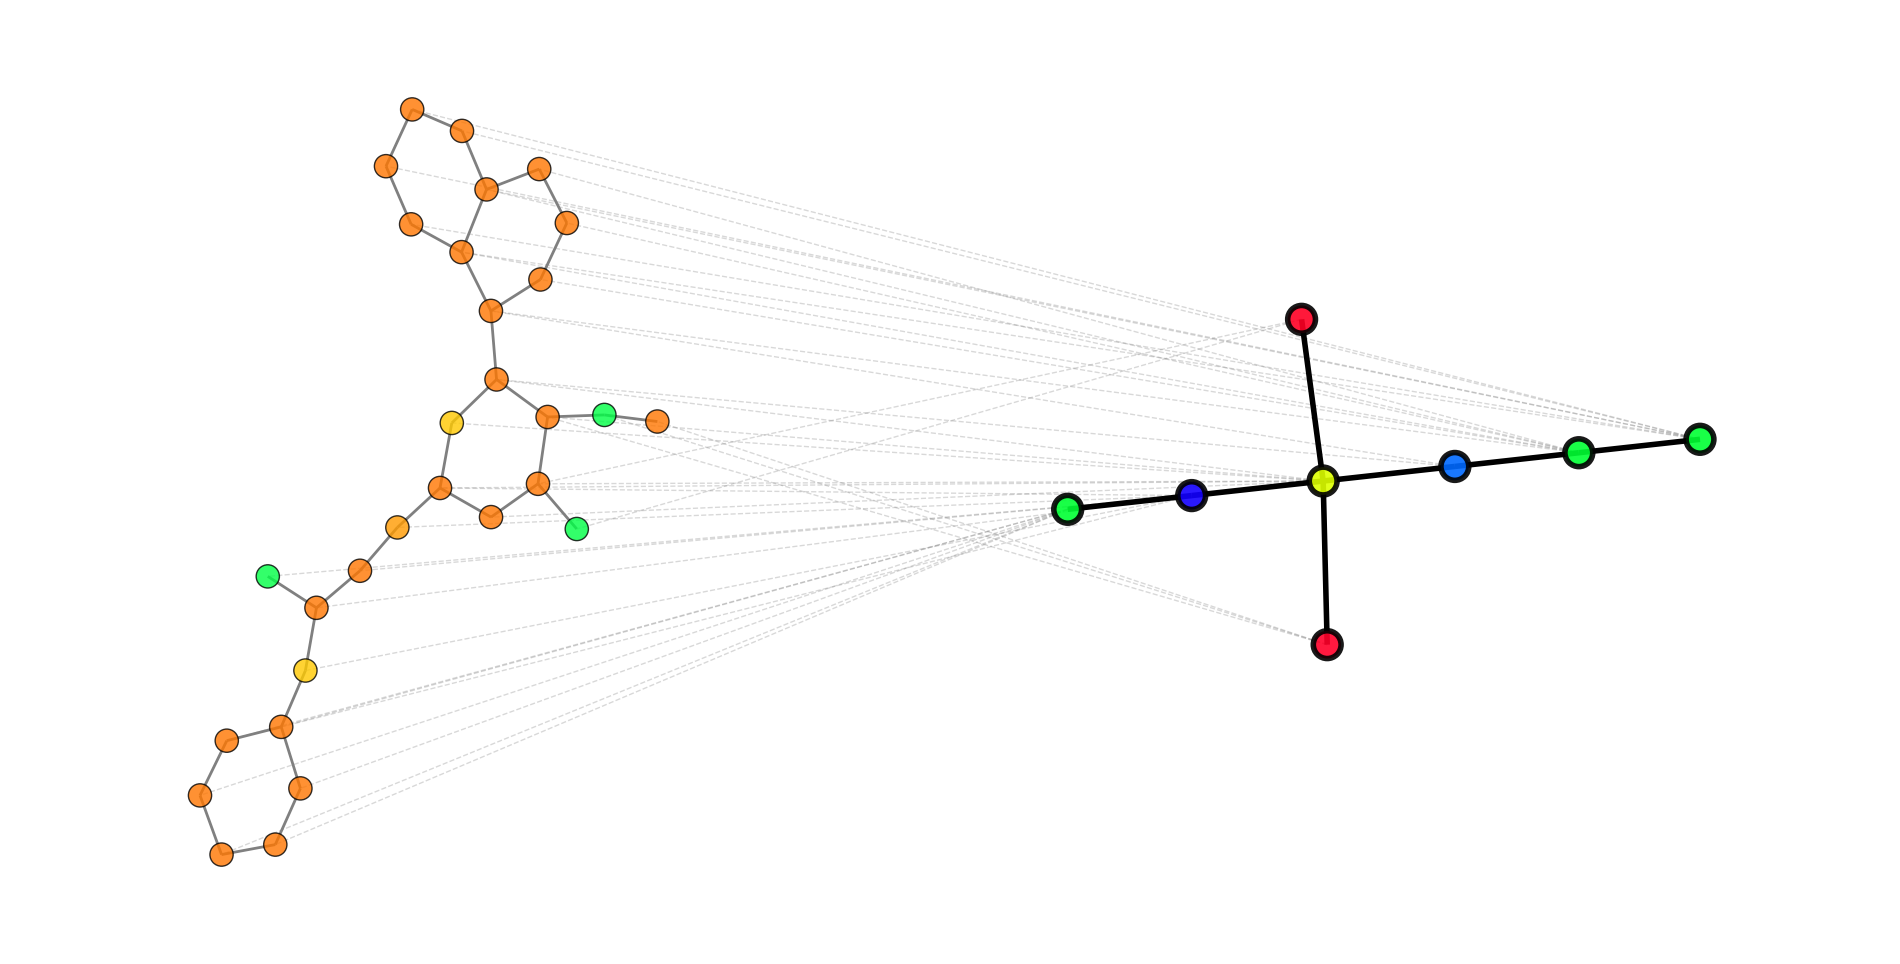

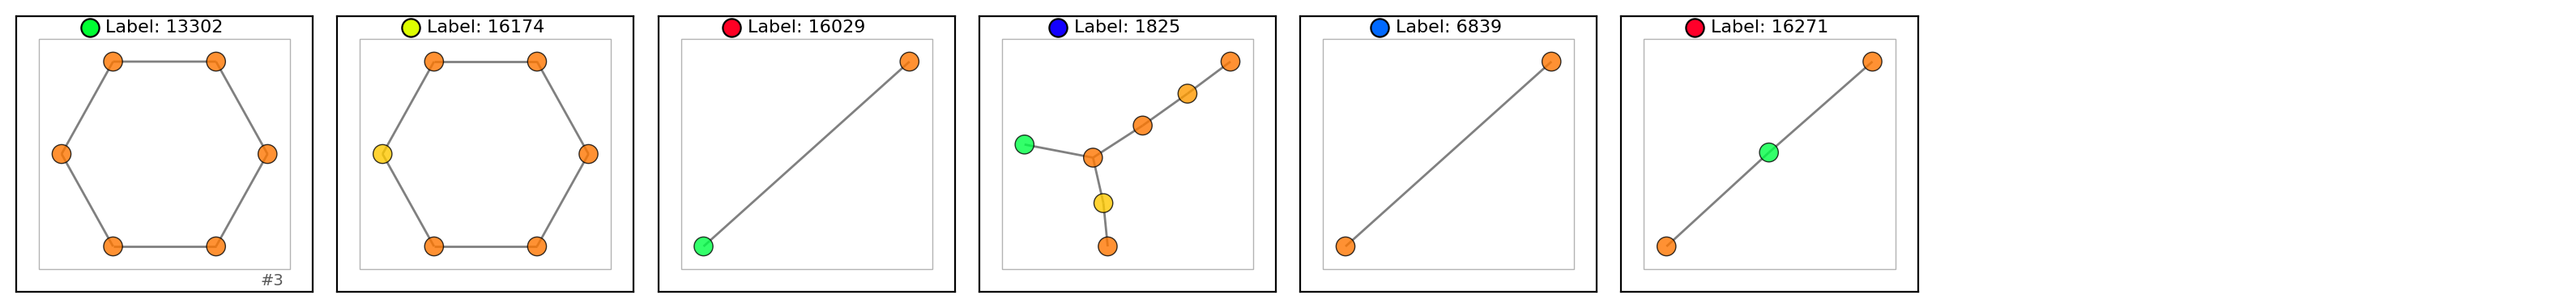

sample 1 | seed index 460
seed molecule


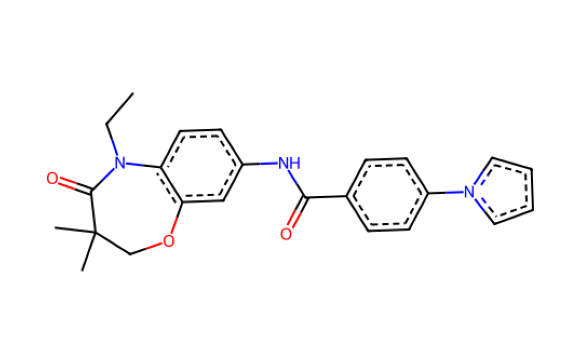

seed interpretation graph
generated interpretation graph
generated molecule instances (3)


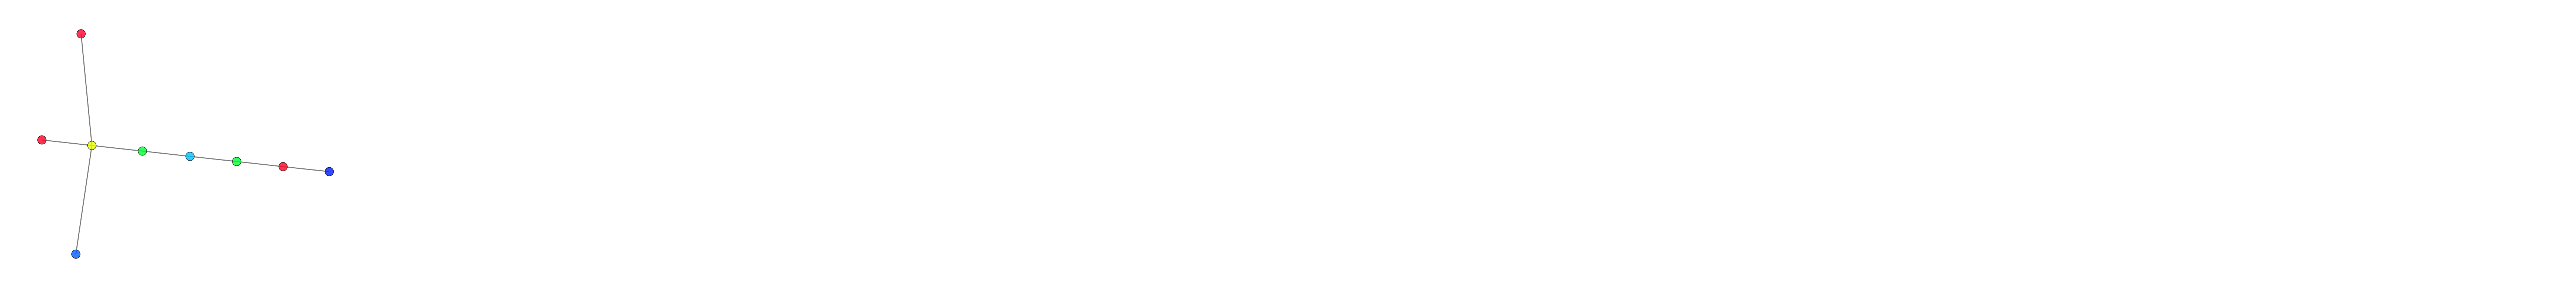

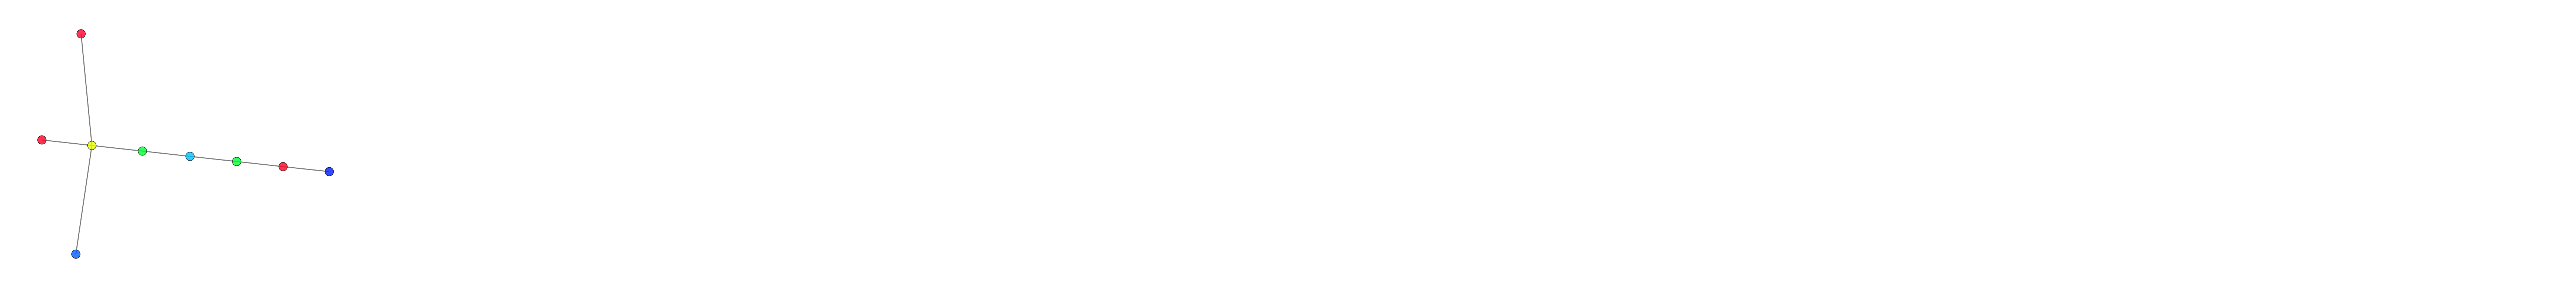

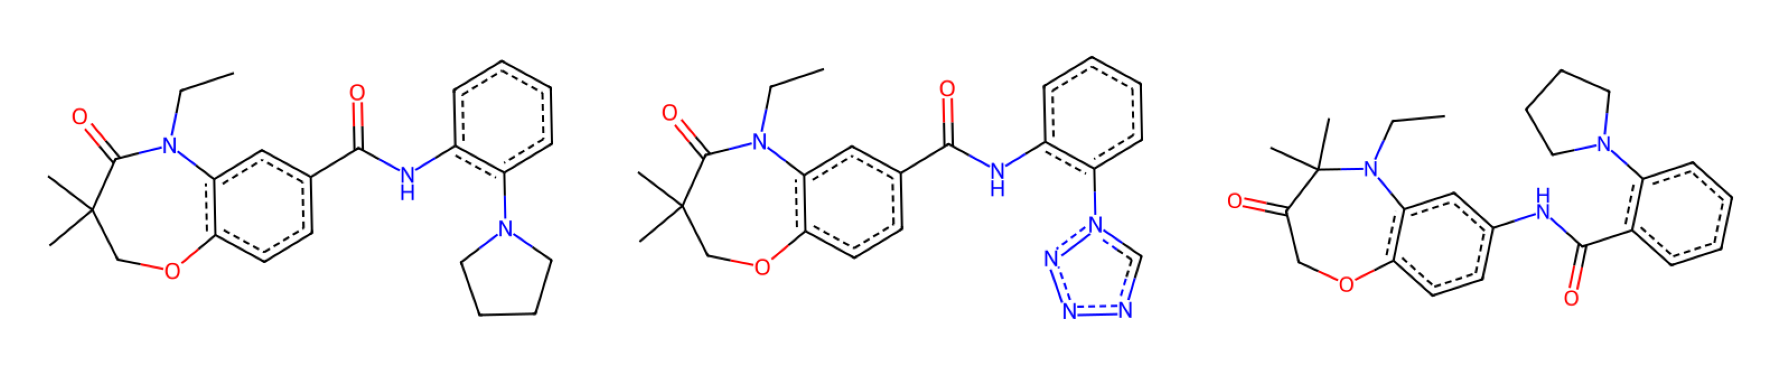

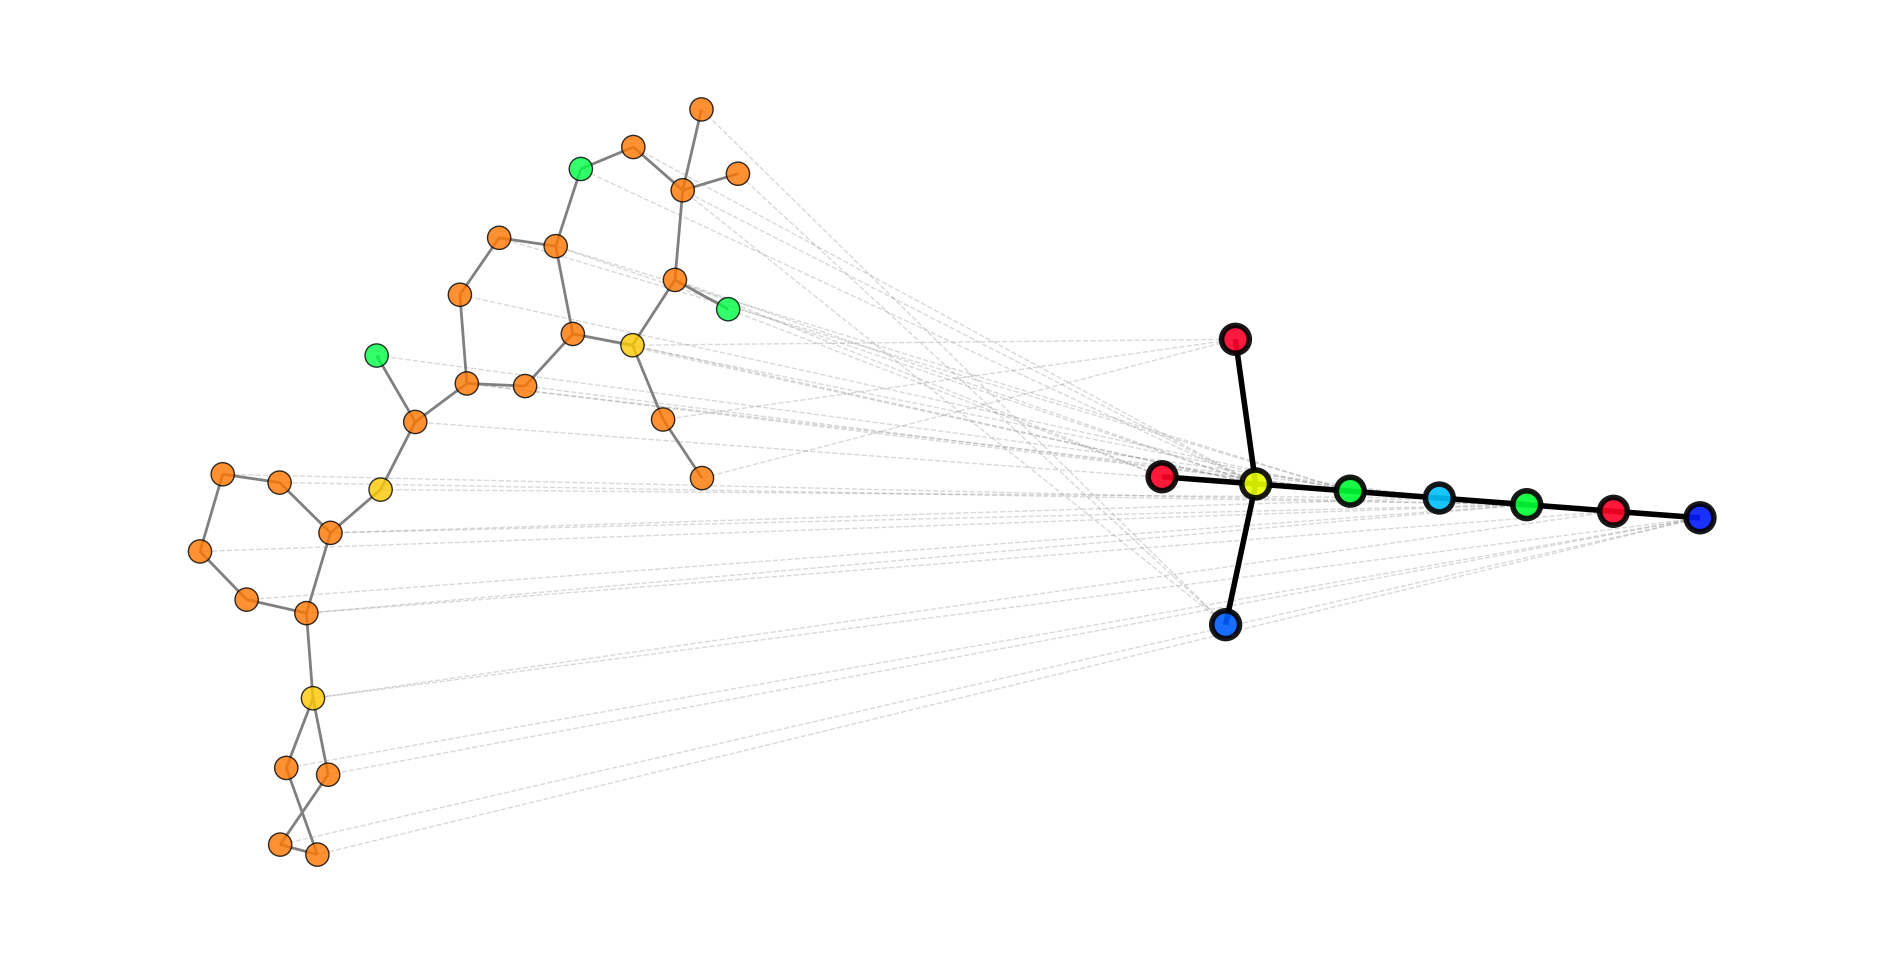

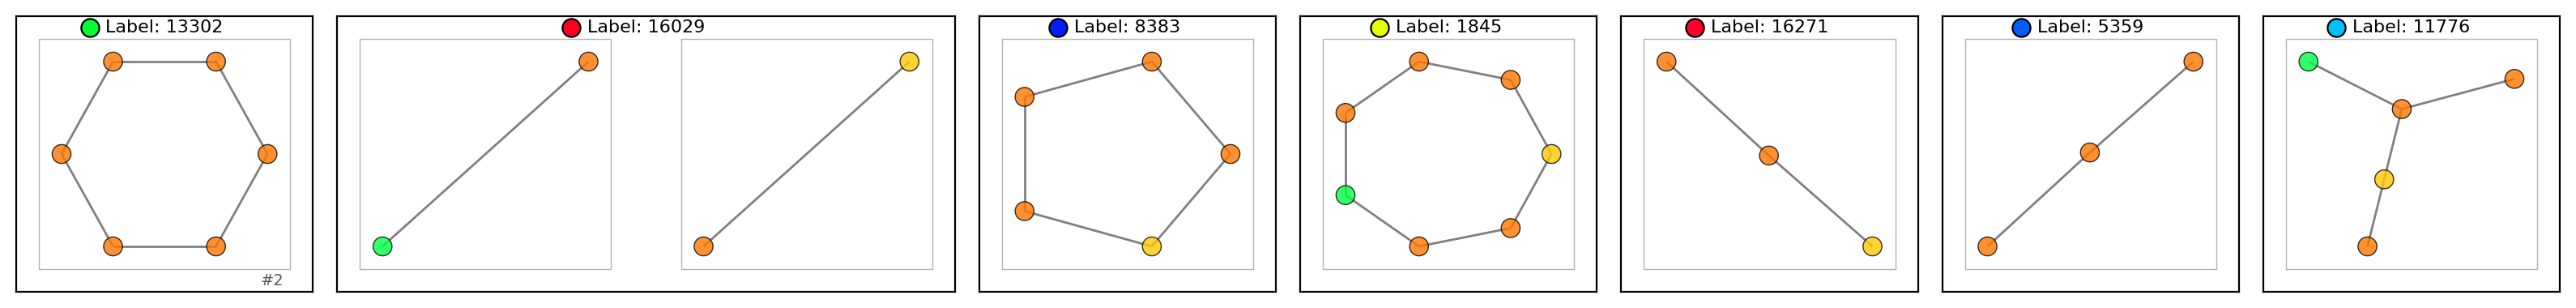

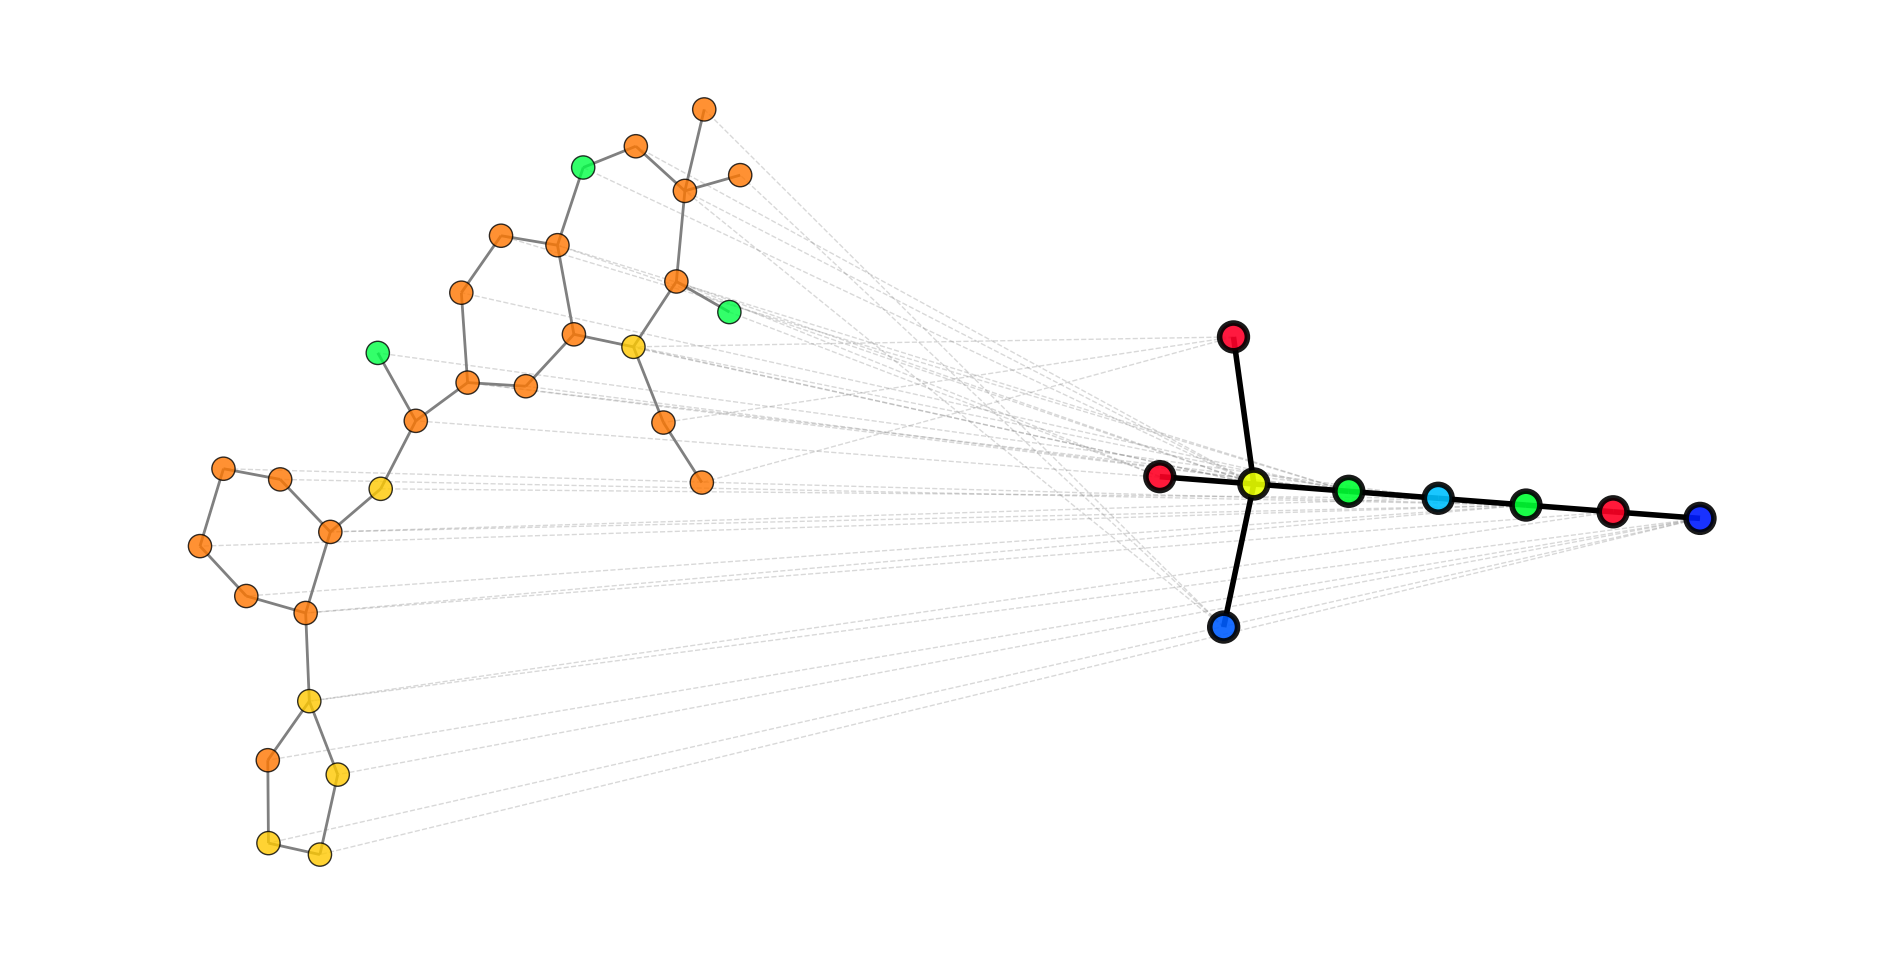

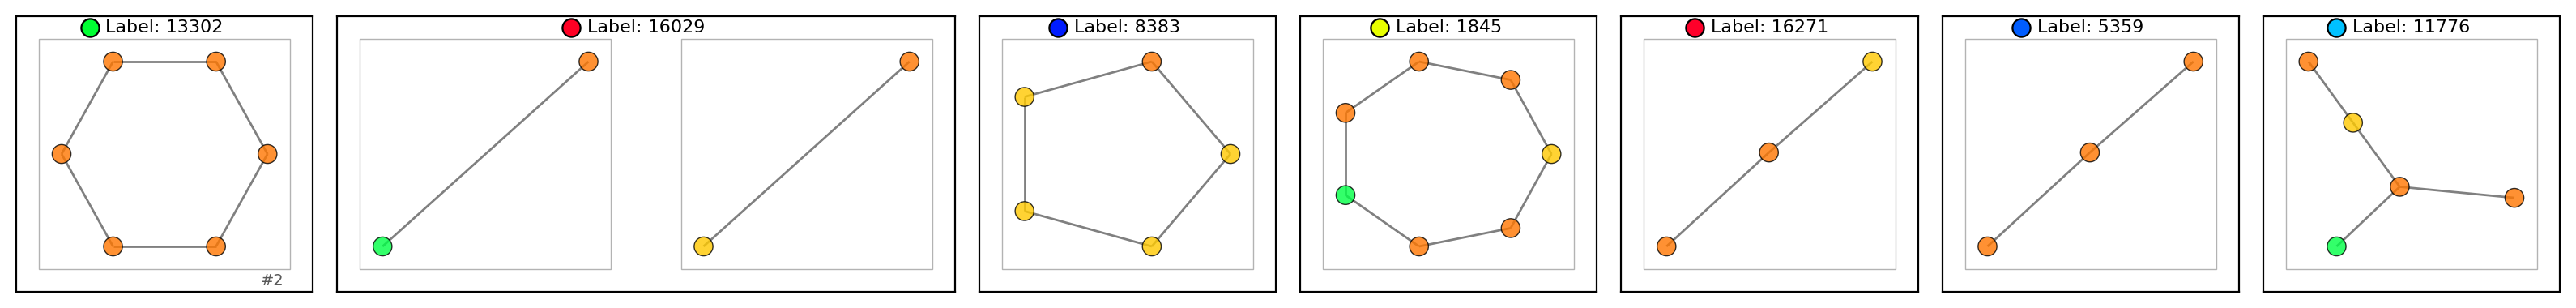

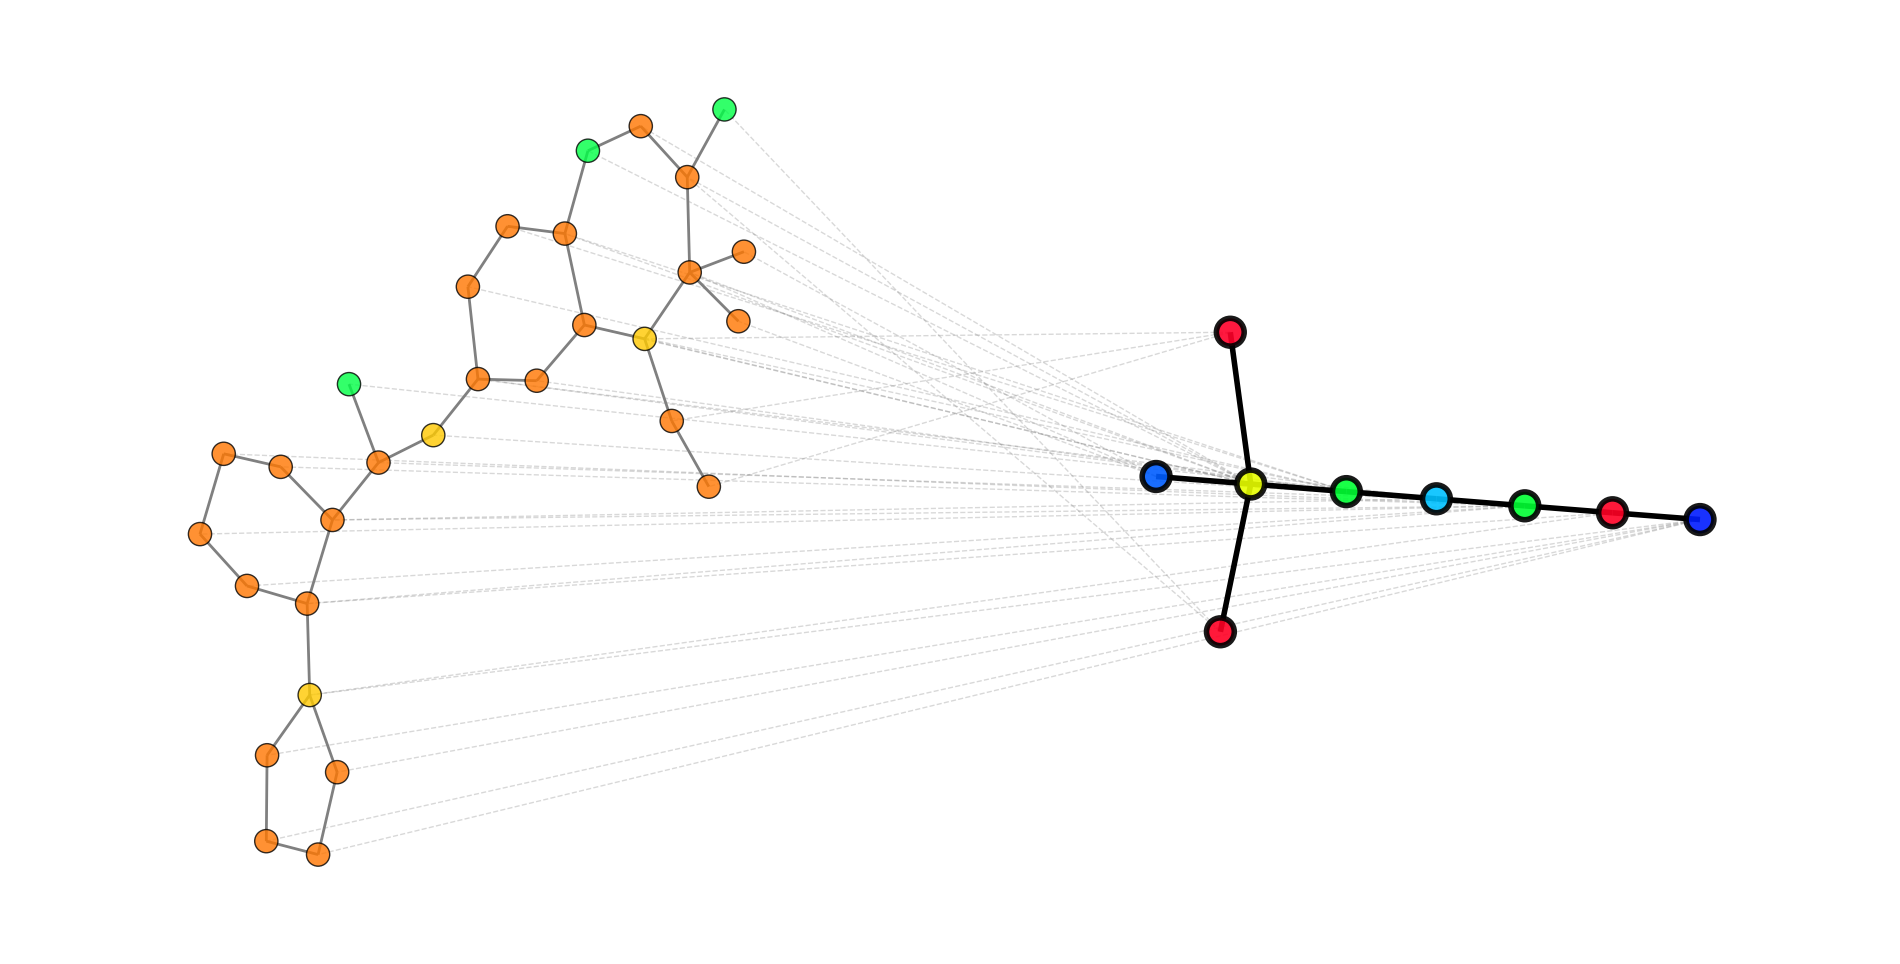

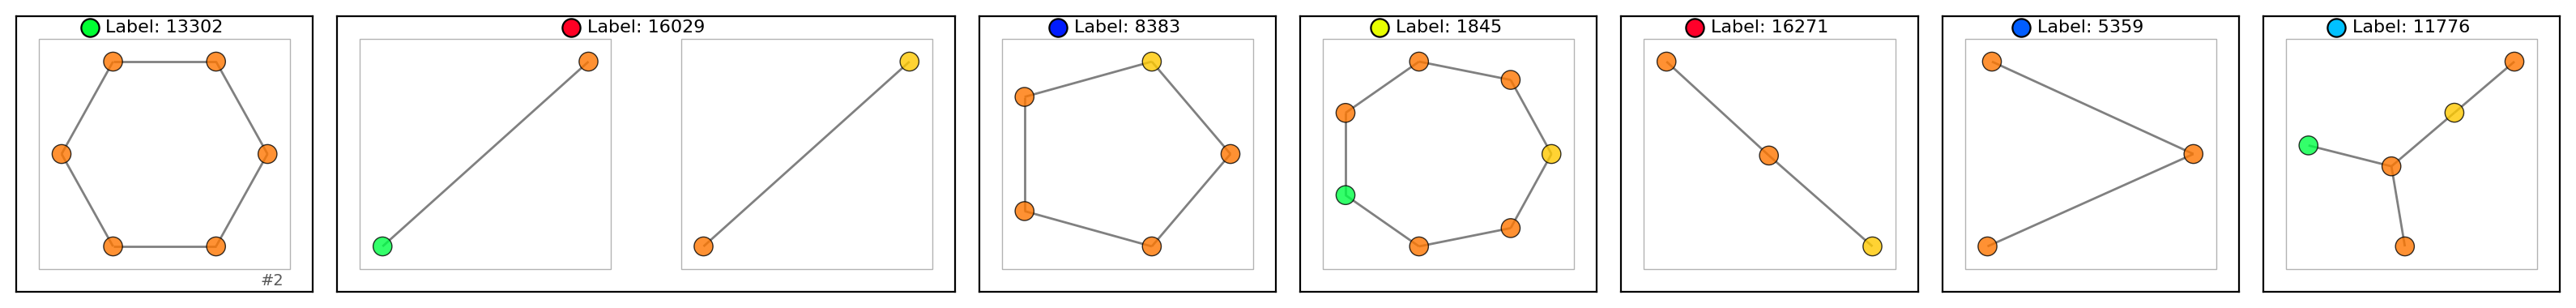

sample 2 | seed index 1465
seed molecule


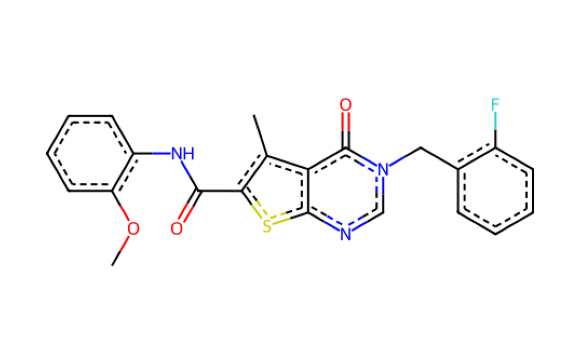

seed interpretation graph
generated interpretation graph
generated molecule instances (3)


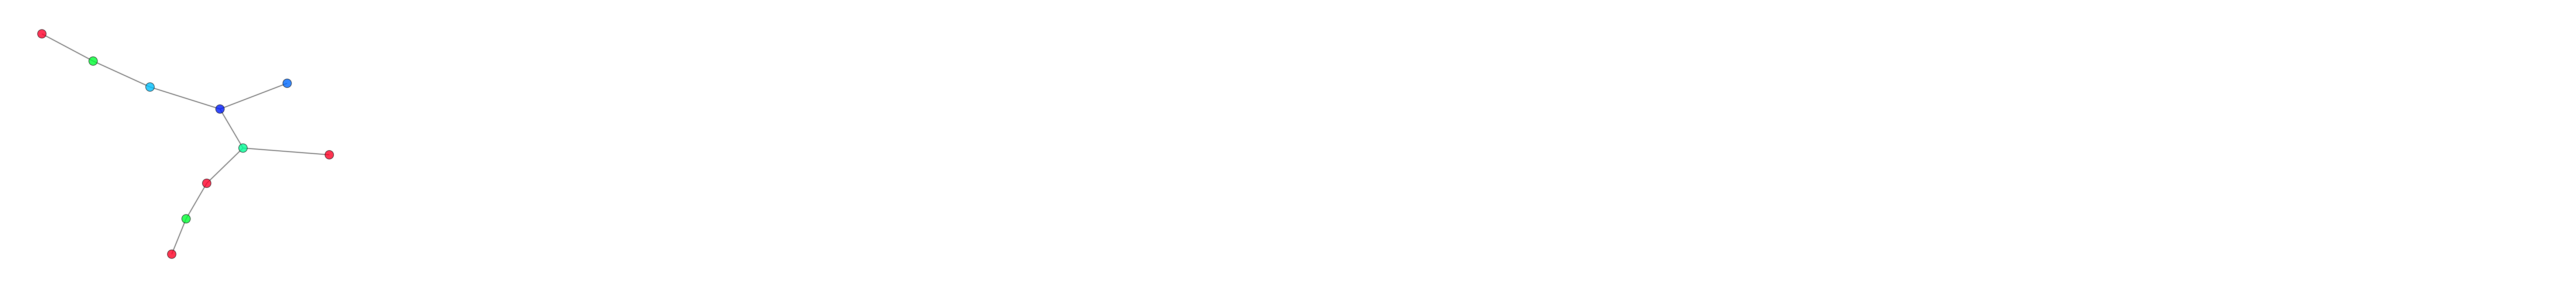

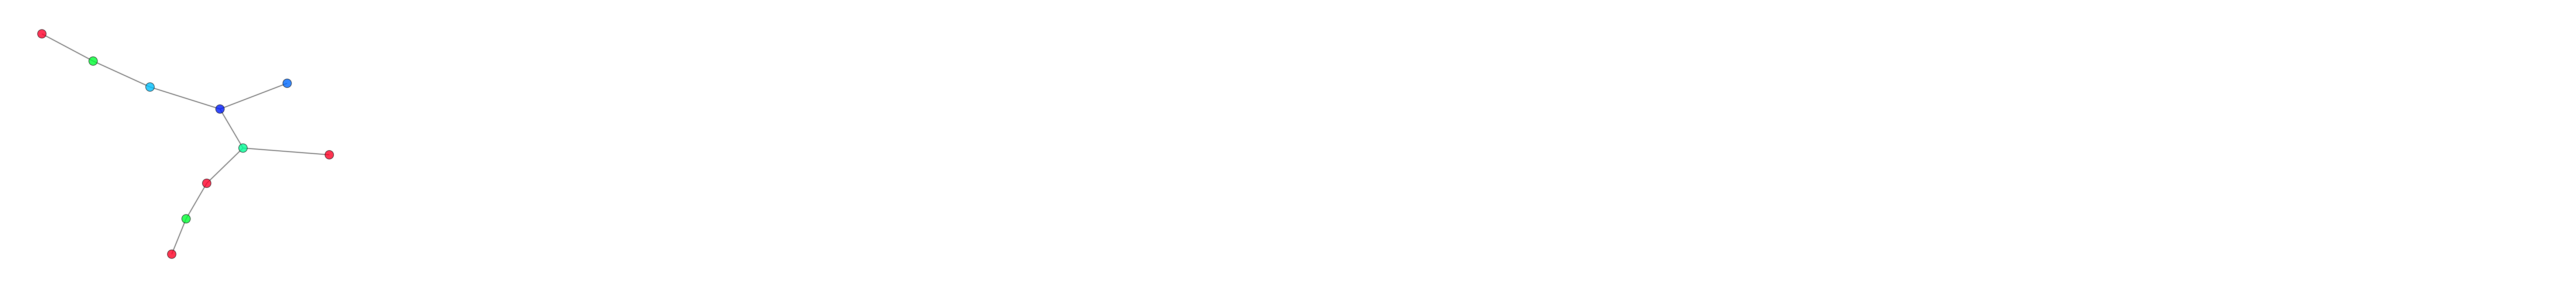

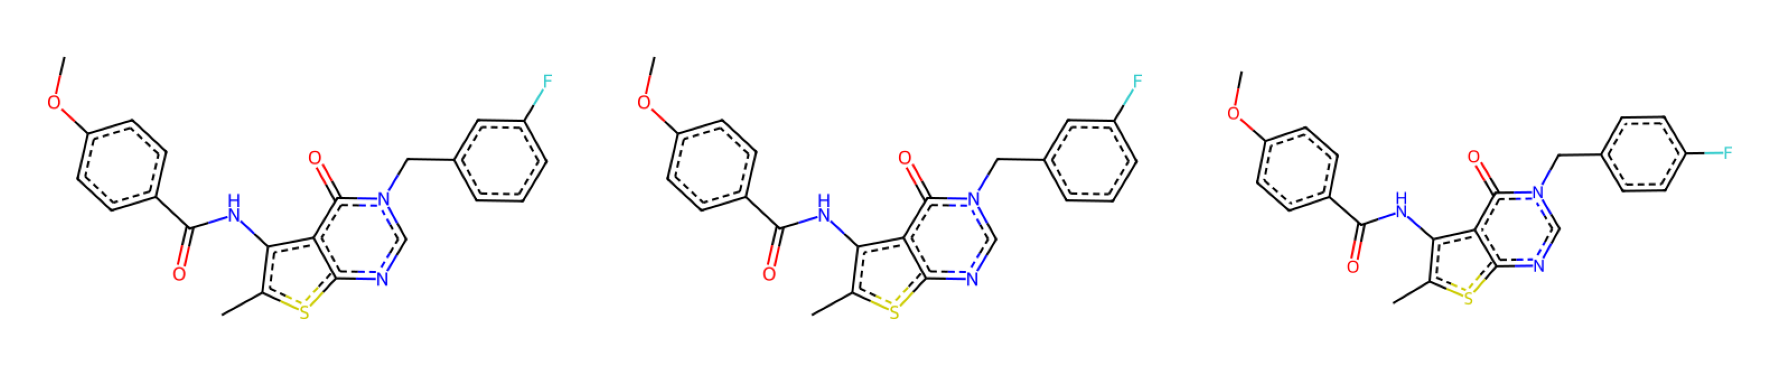

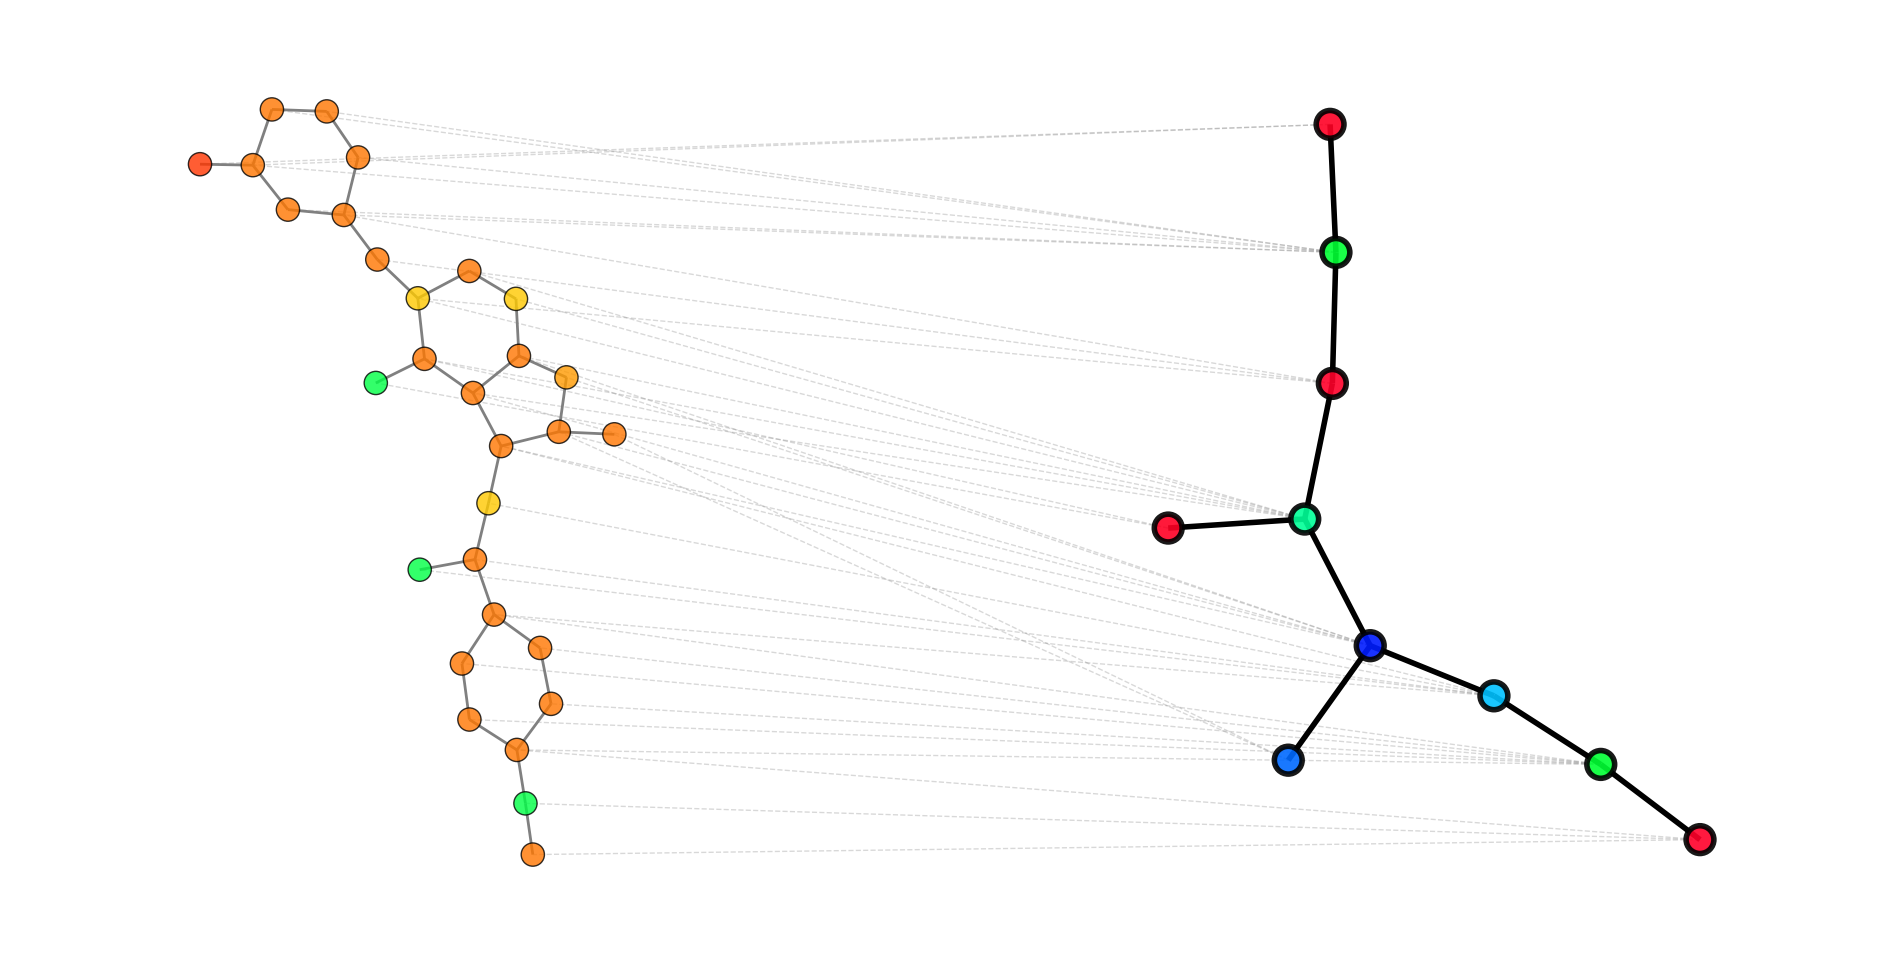

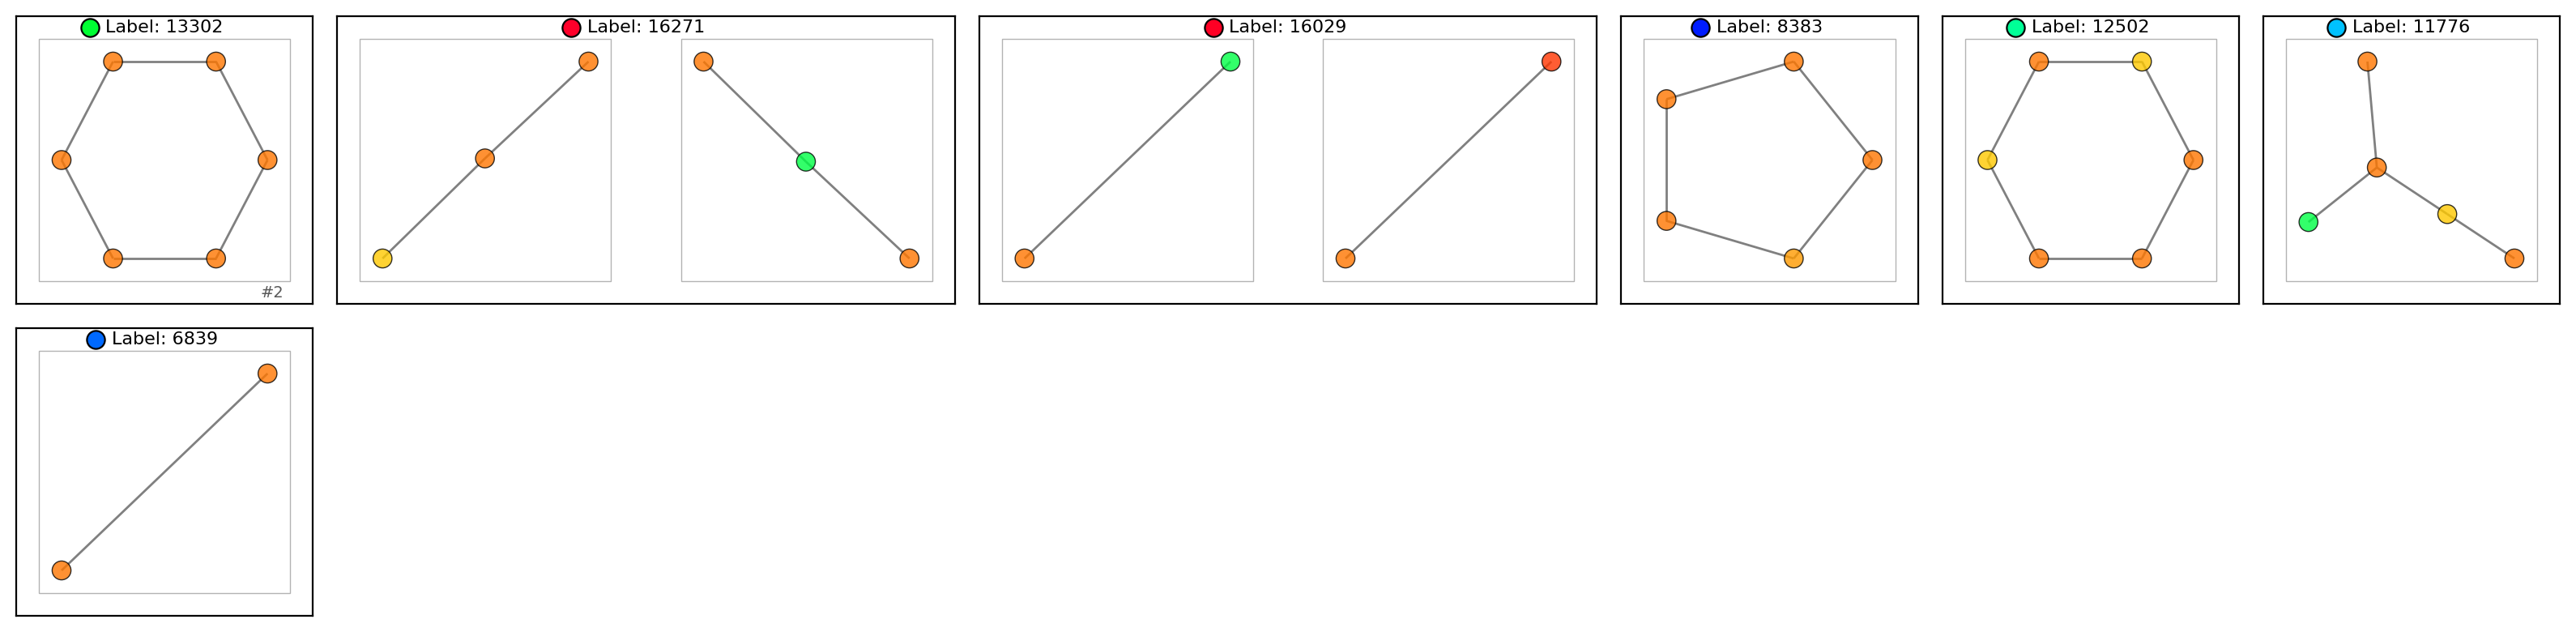

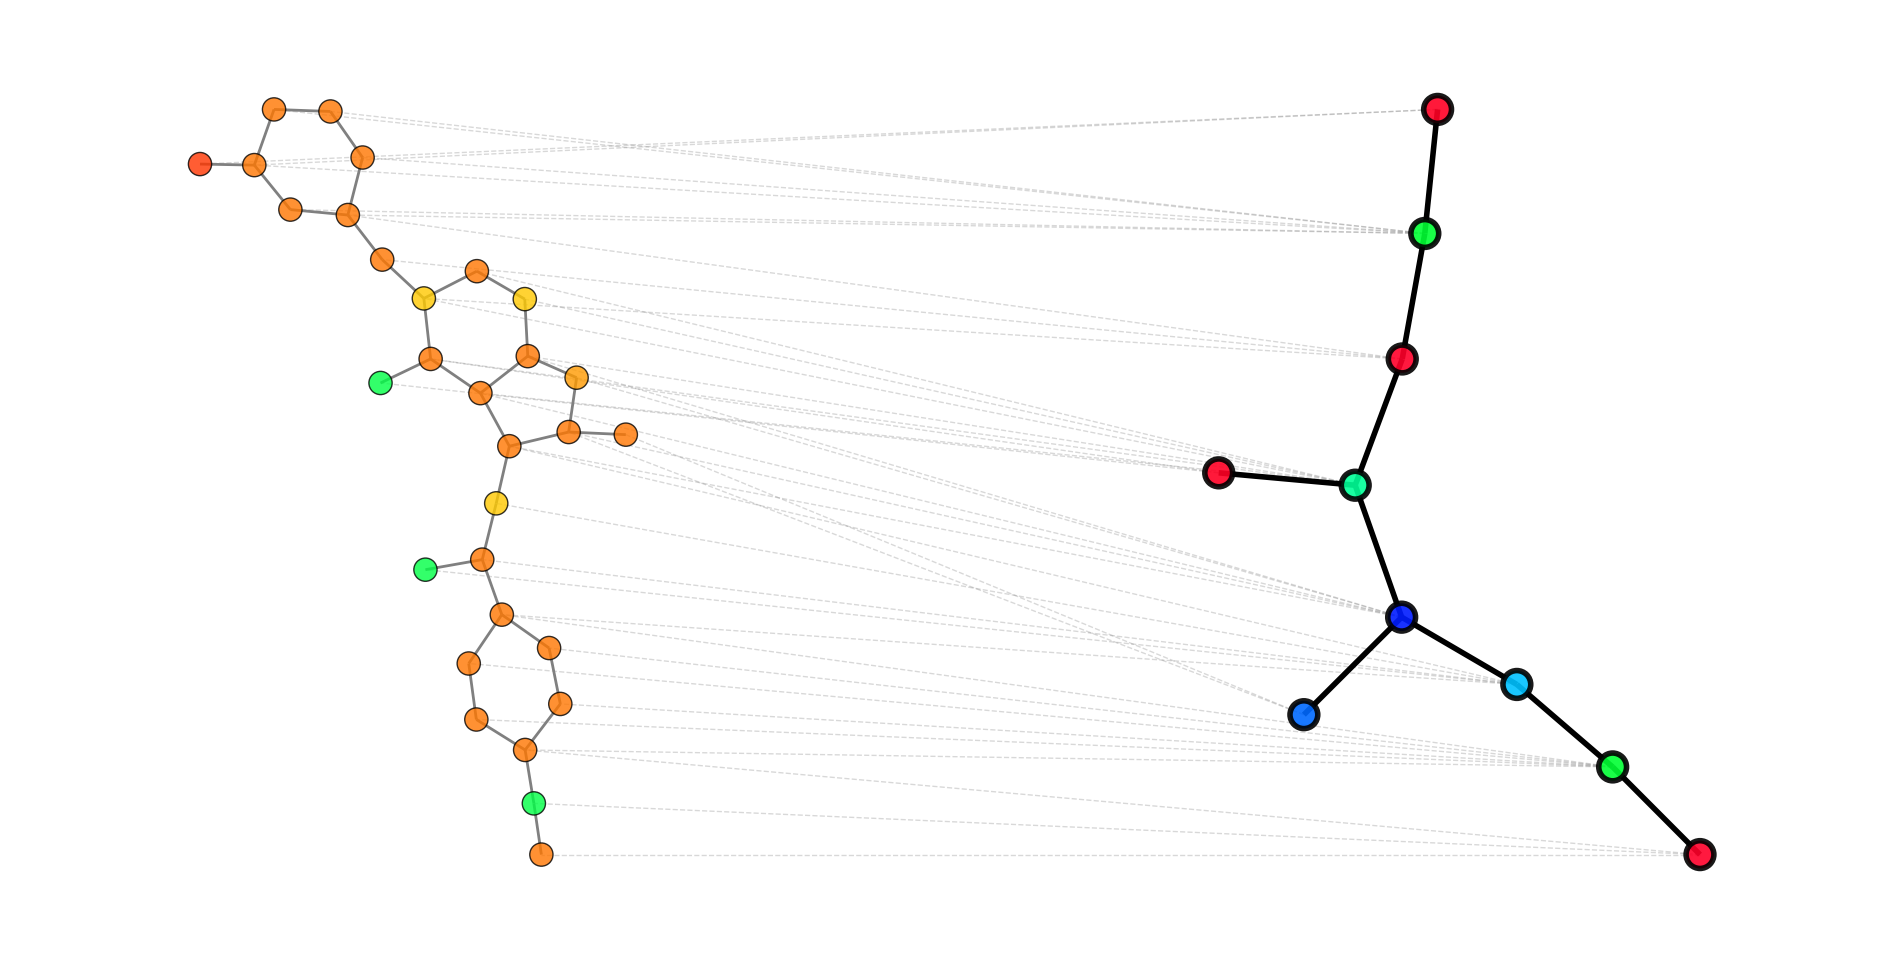

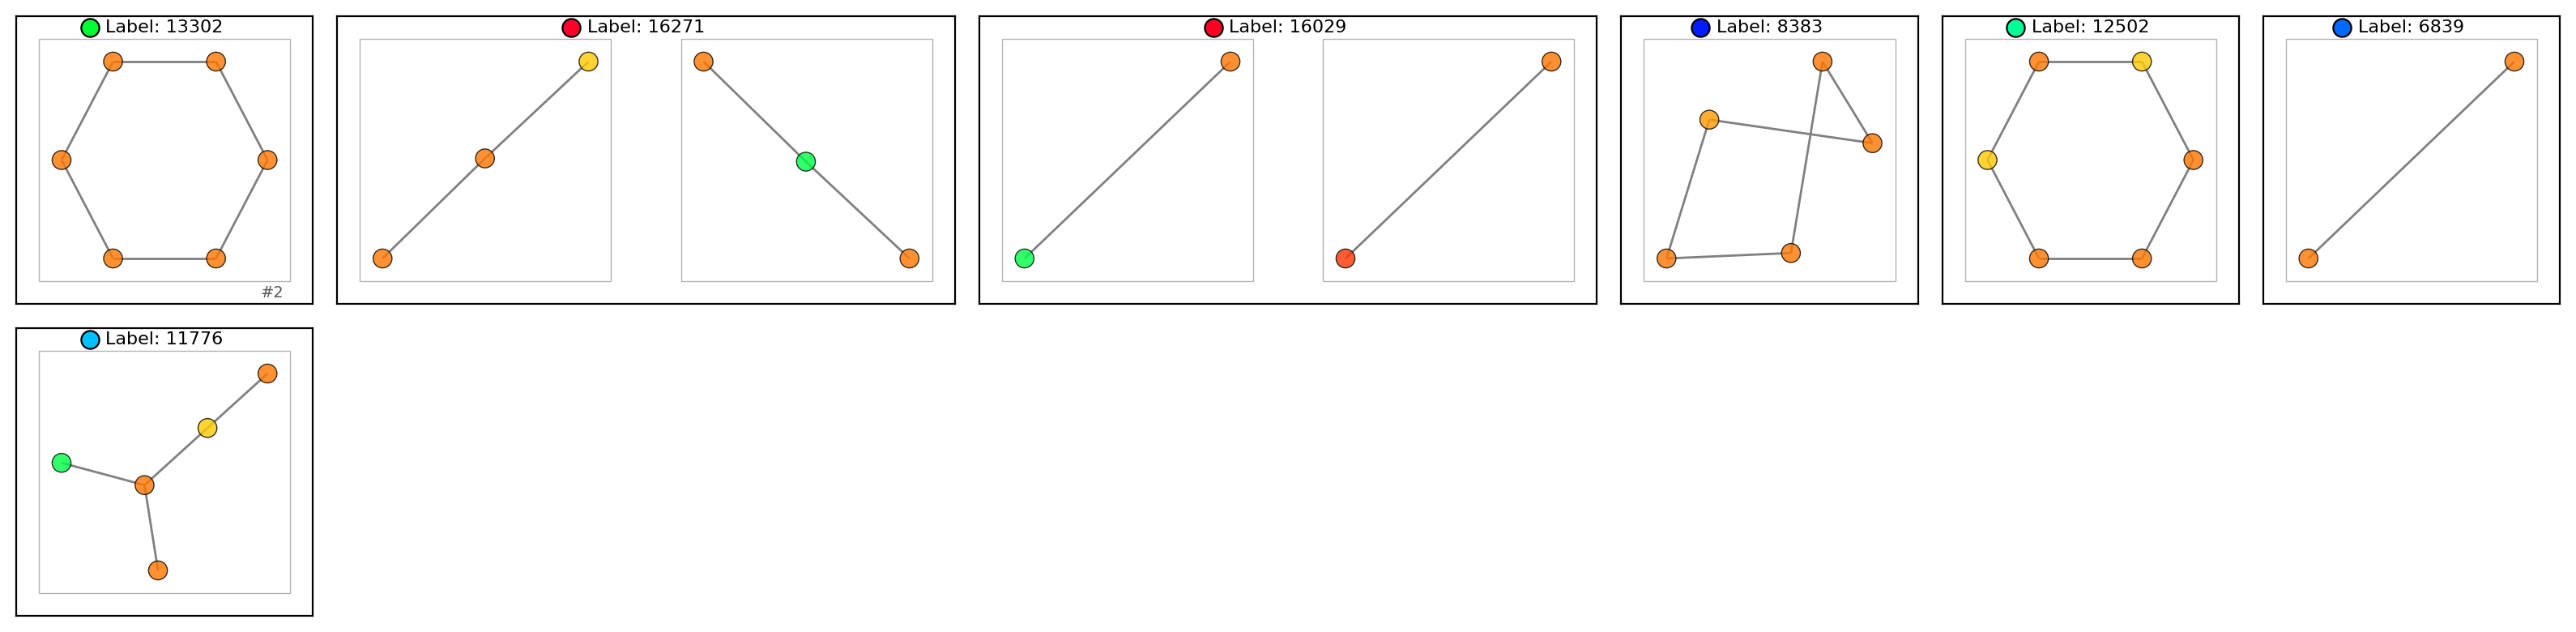

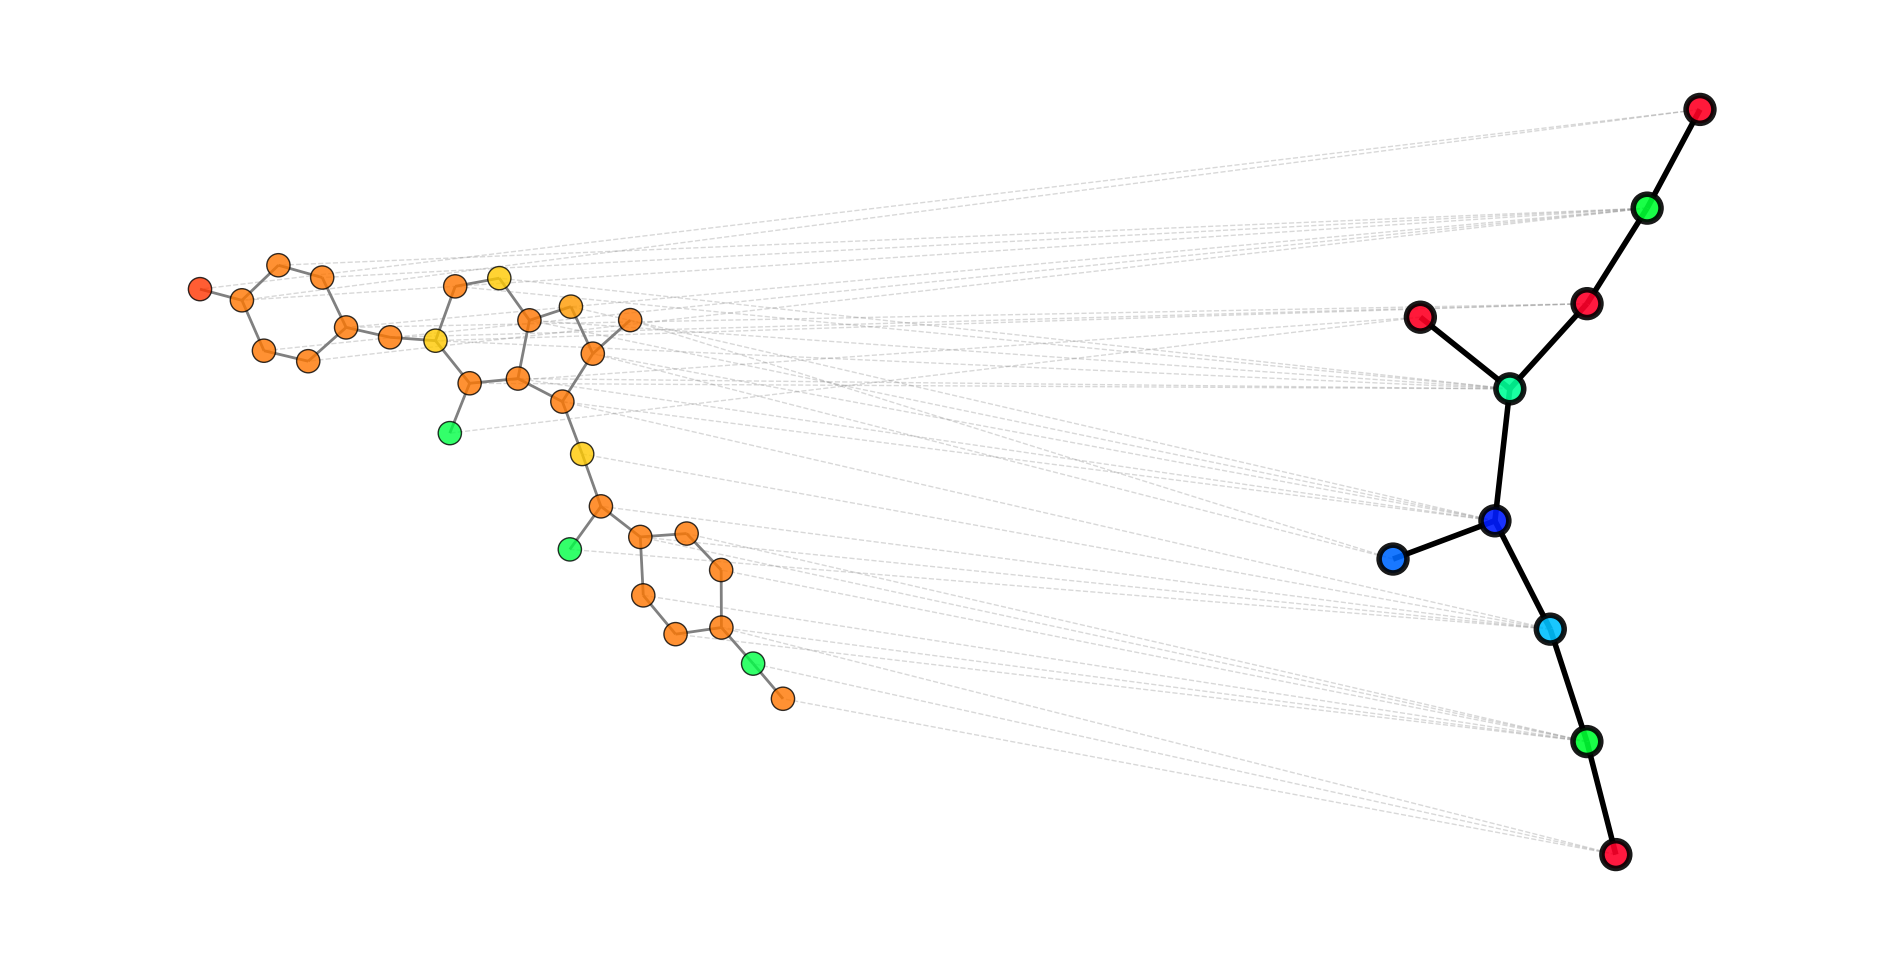

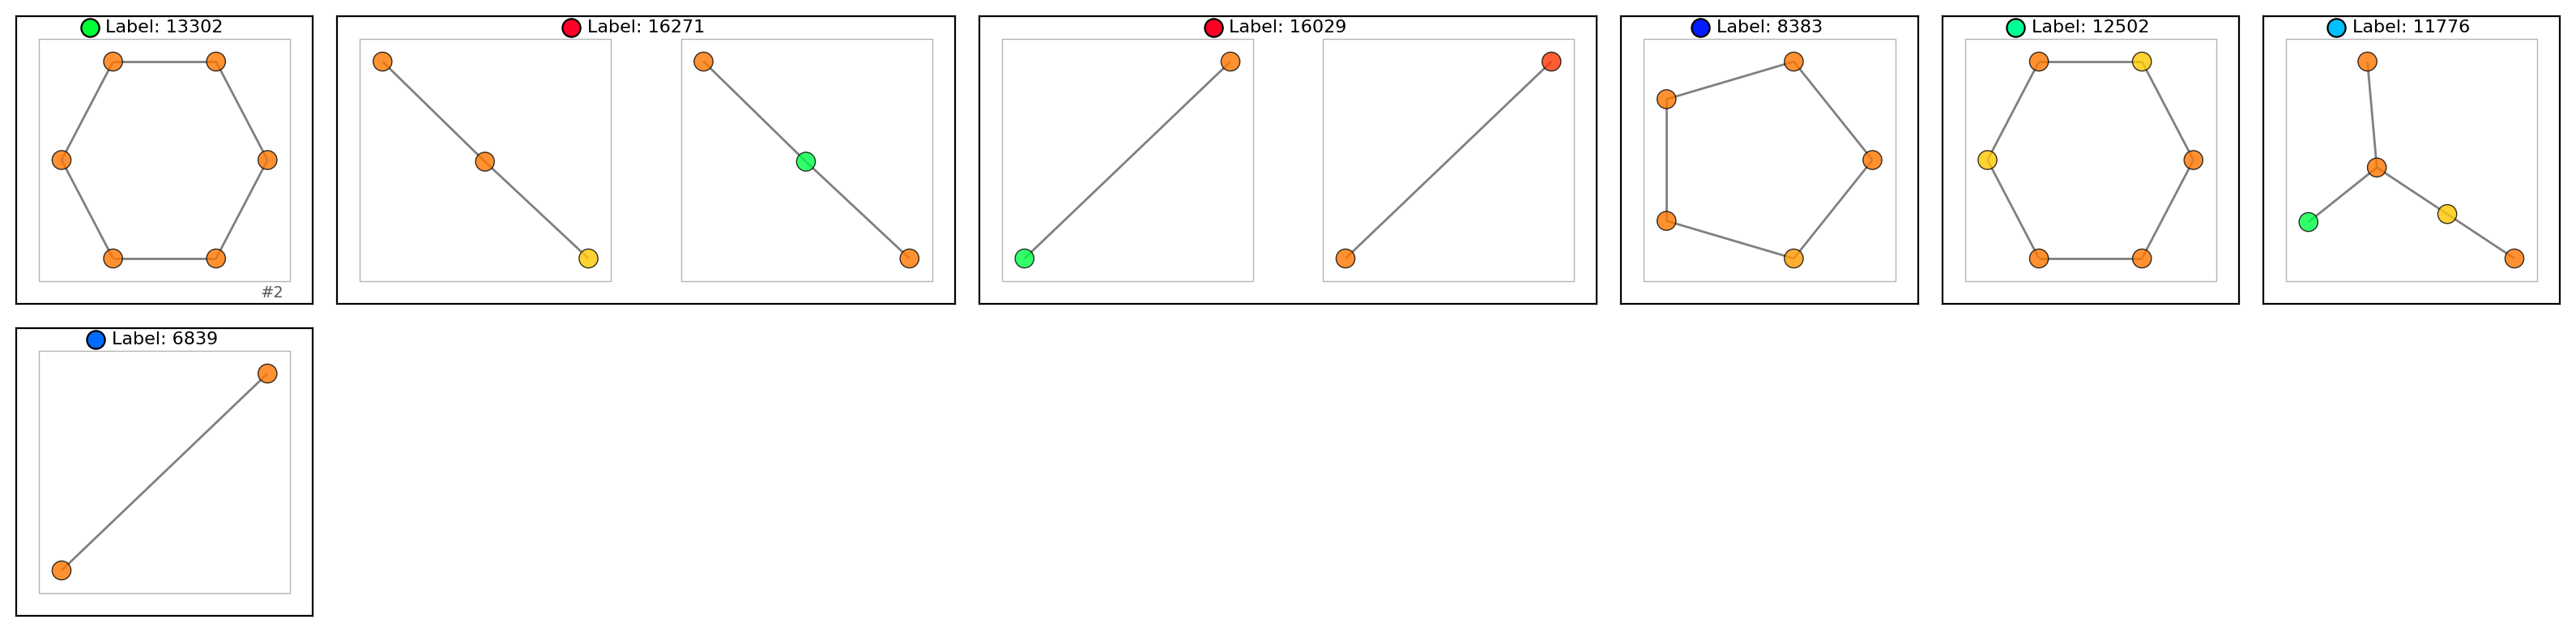

sample 3 | seed index 2582
seed molecule


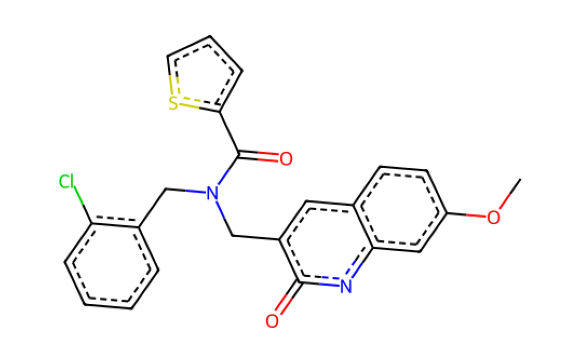

seed interpretation graph
generated interpretation graph
generated molecule instances (3)


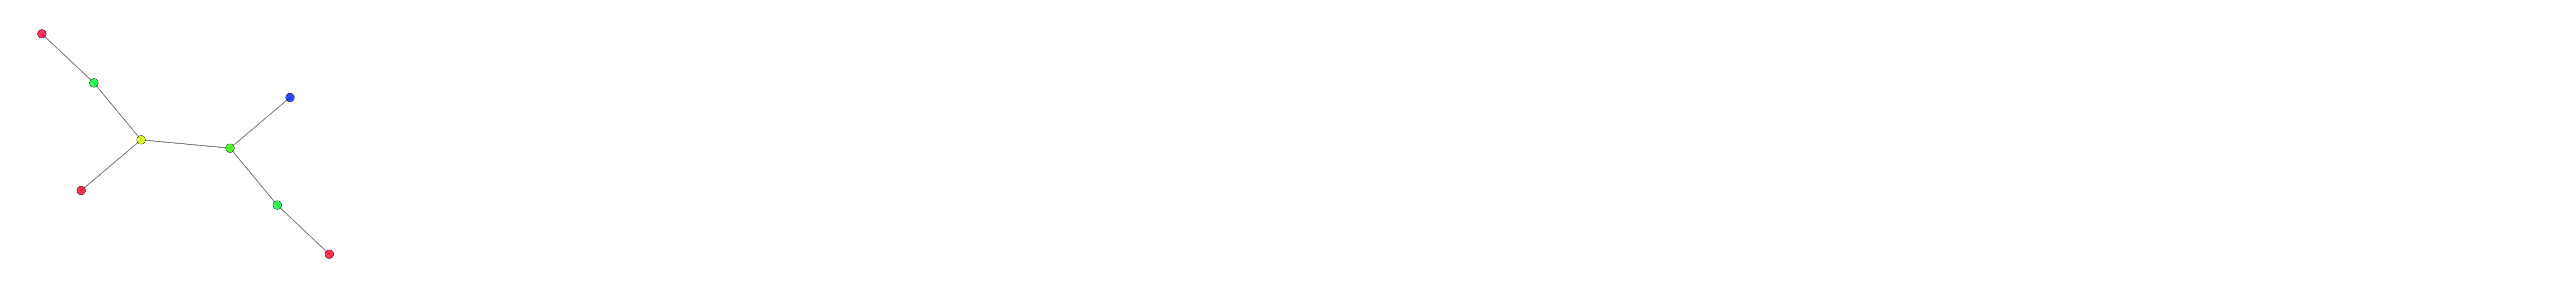

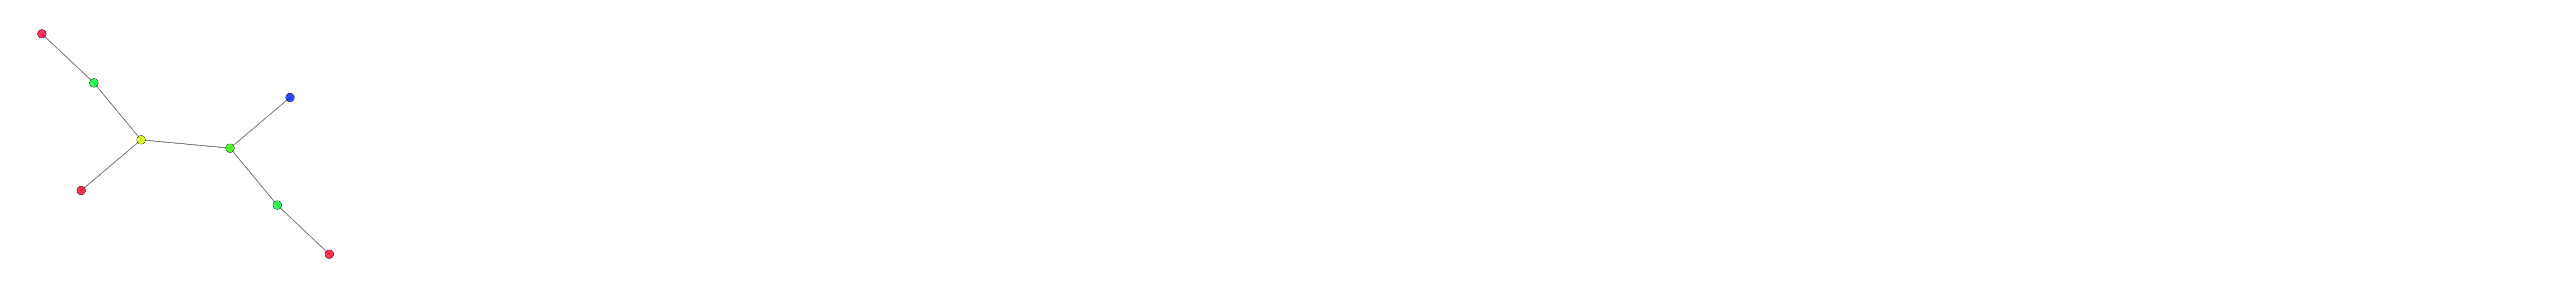

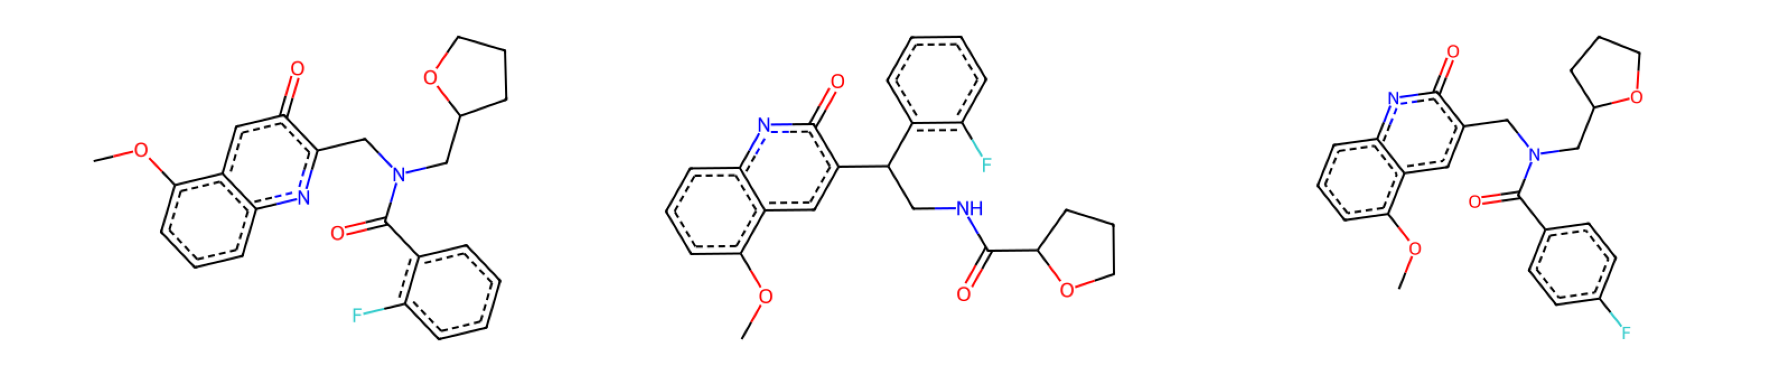

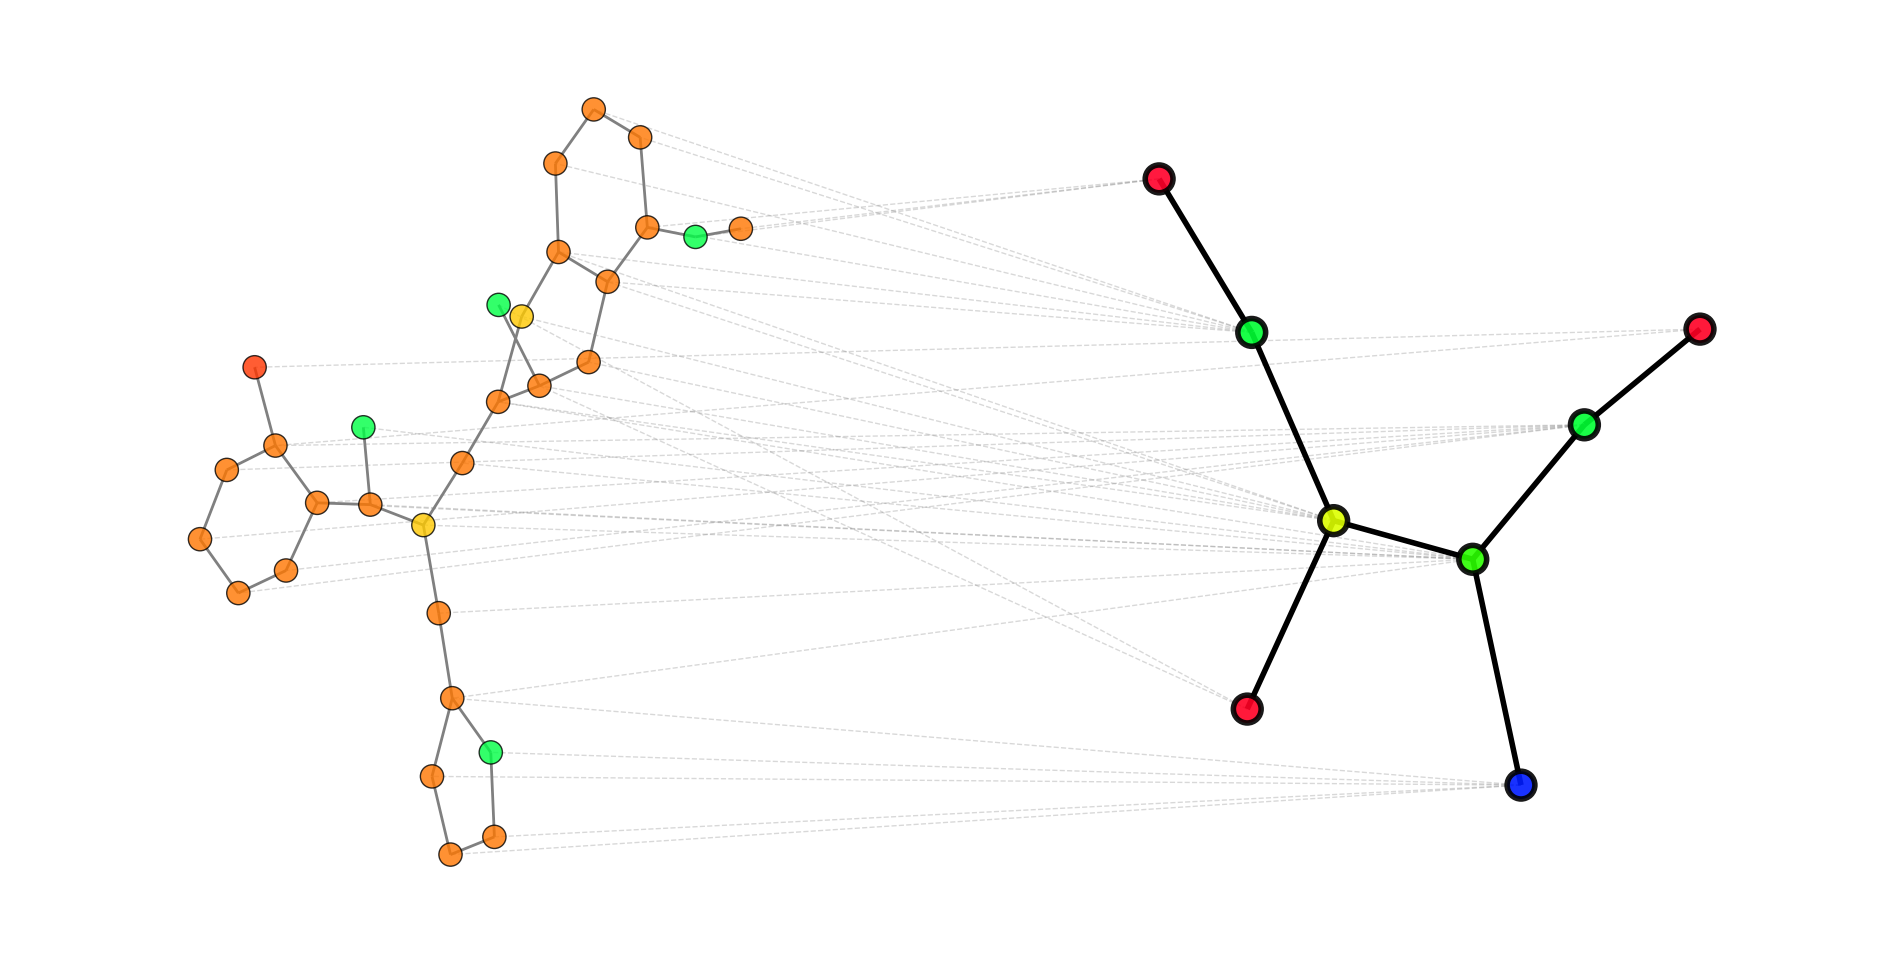

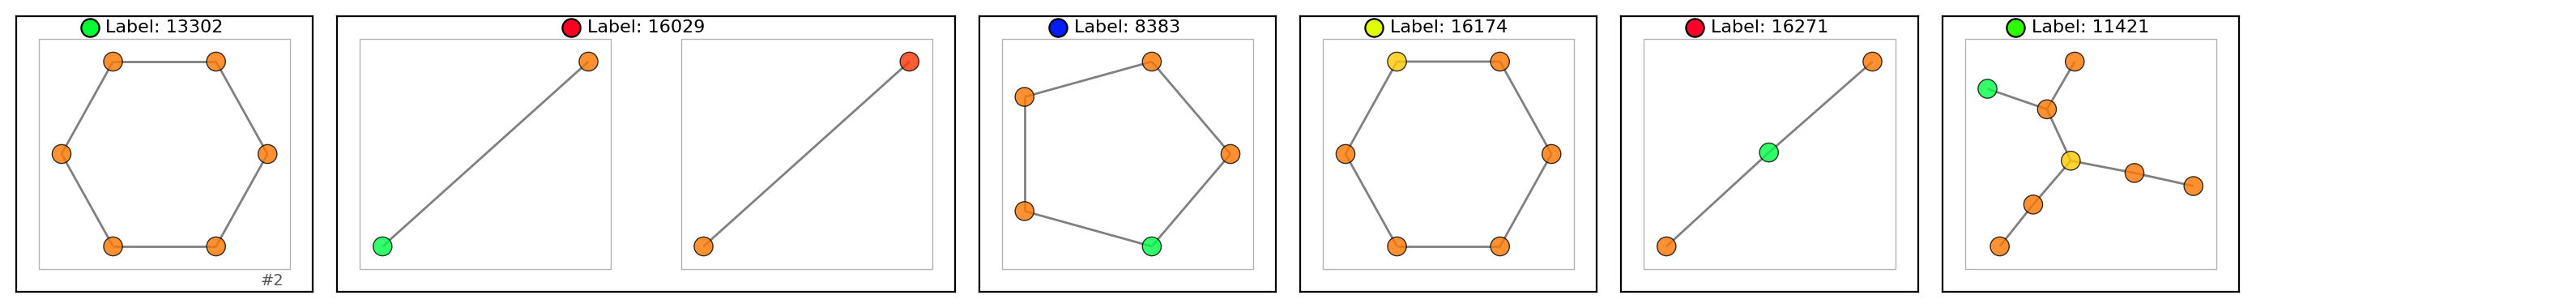

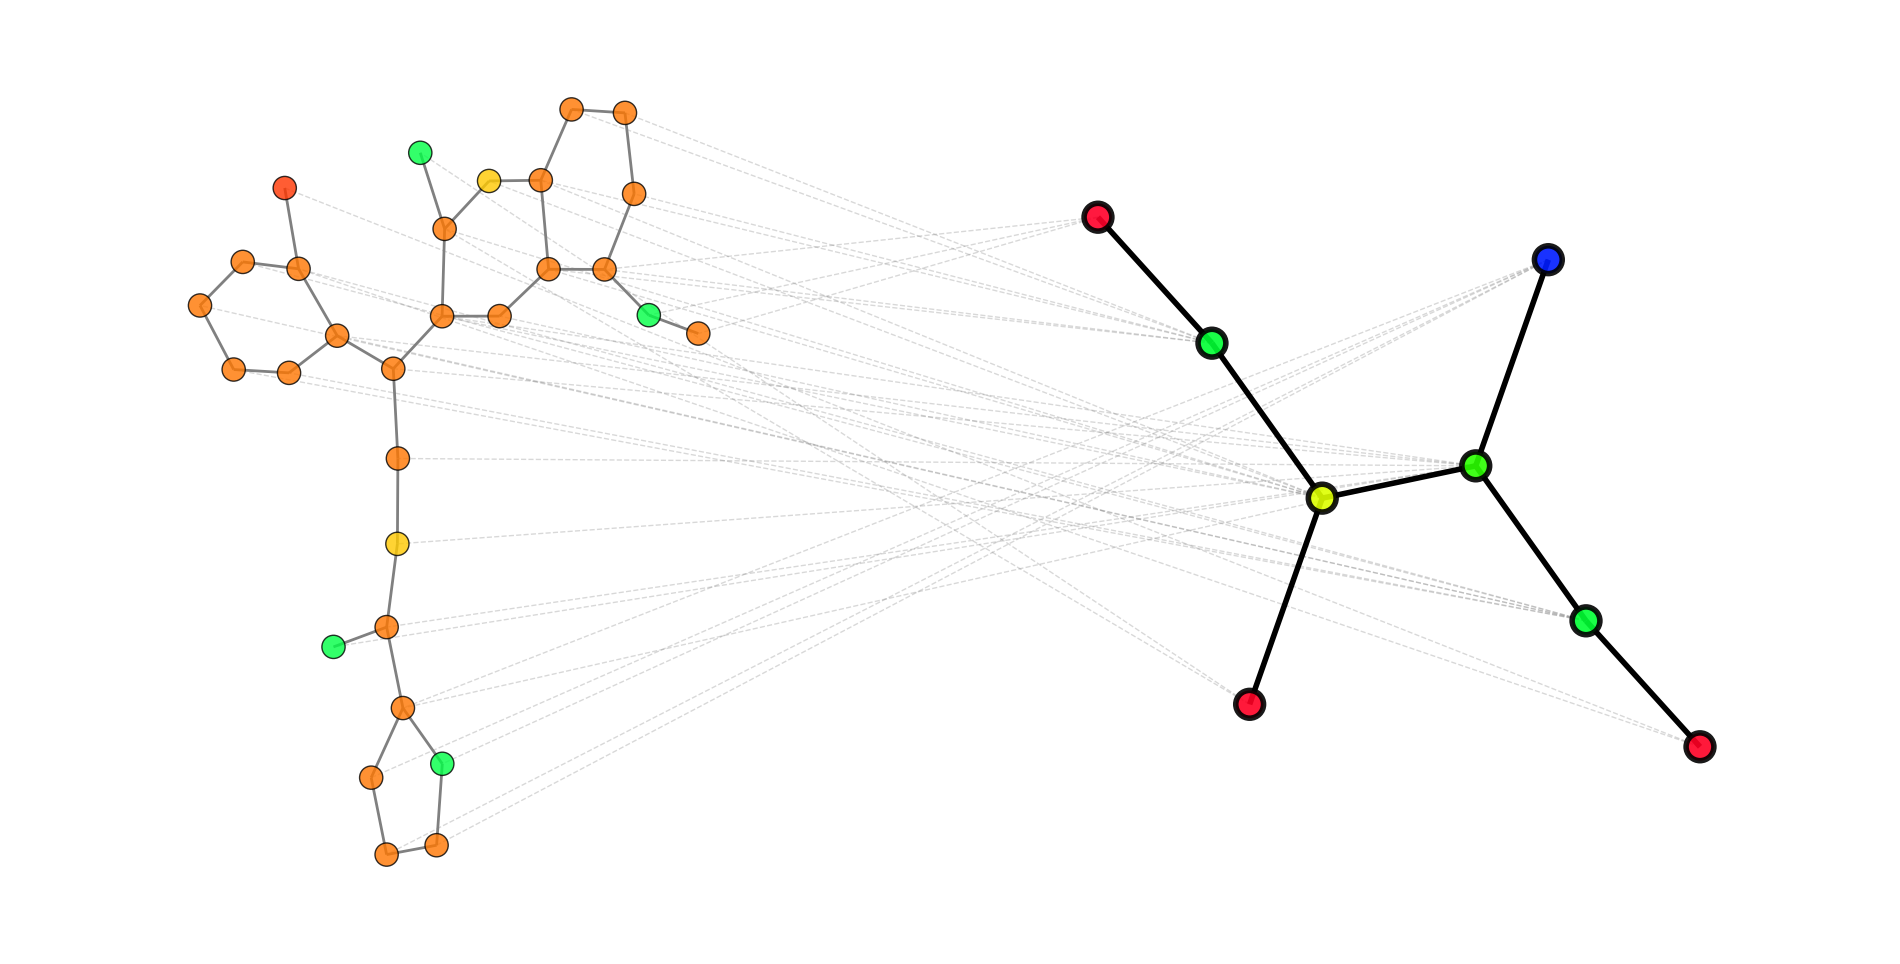

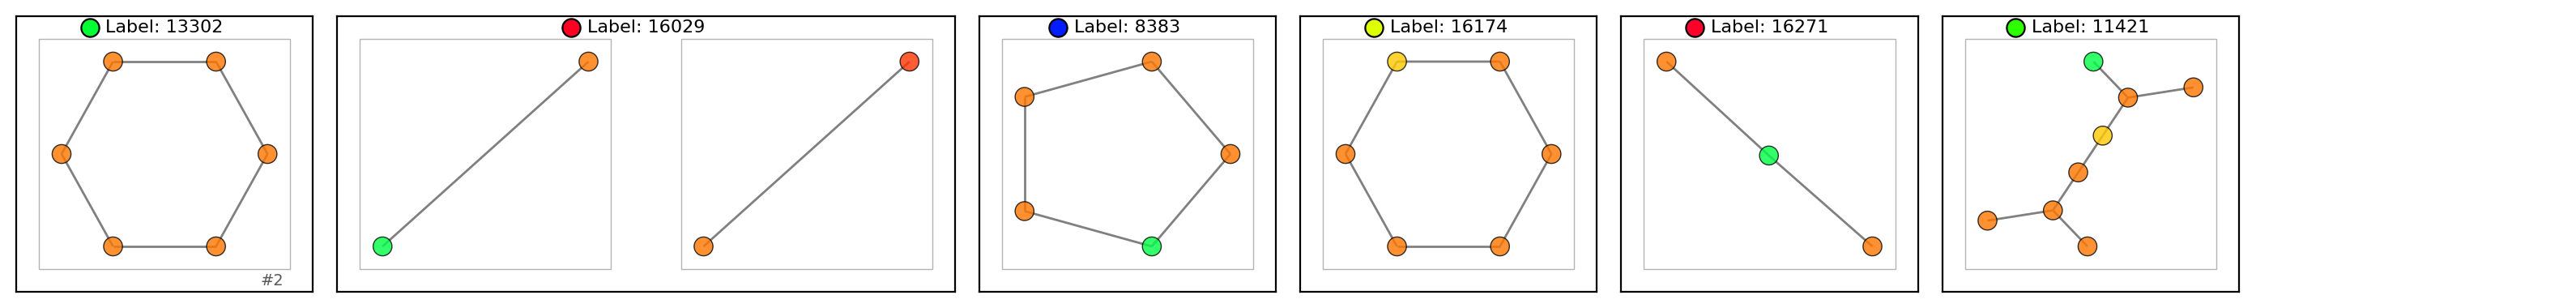

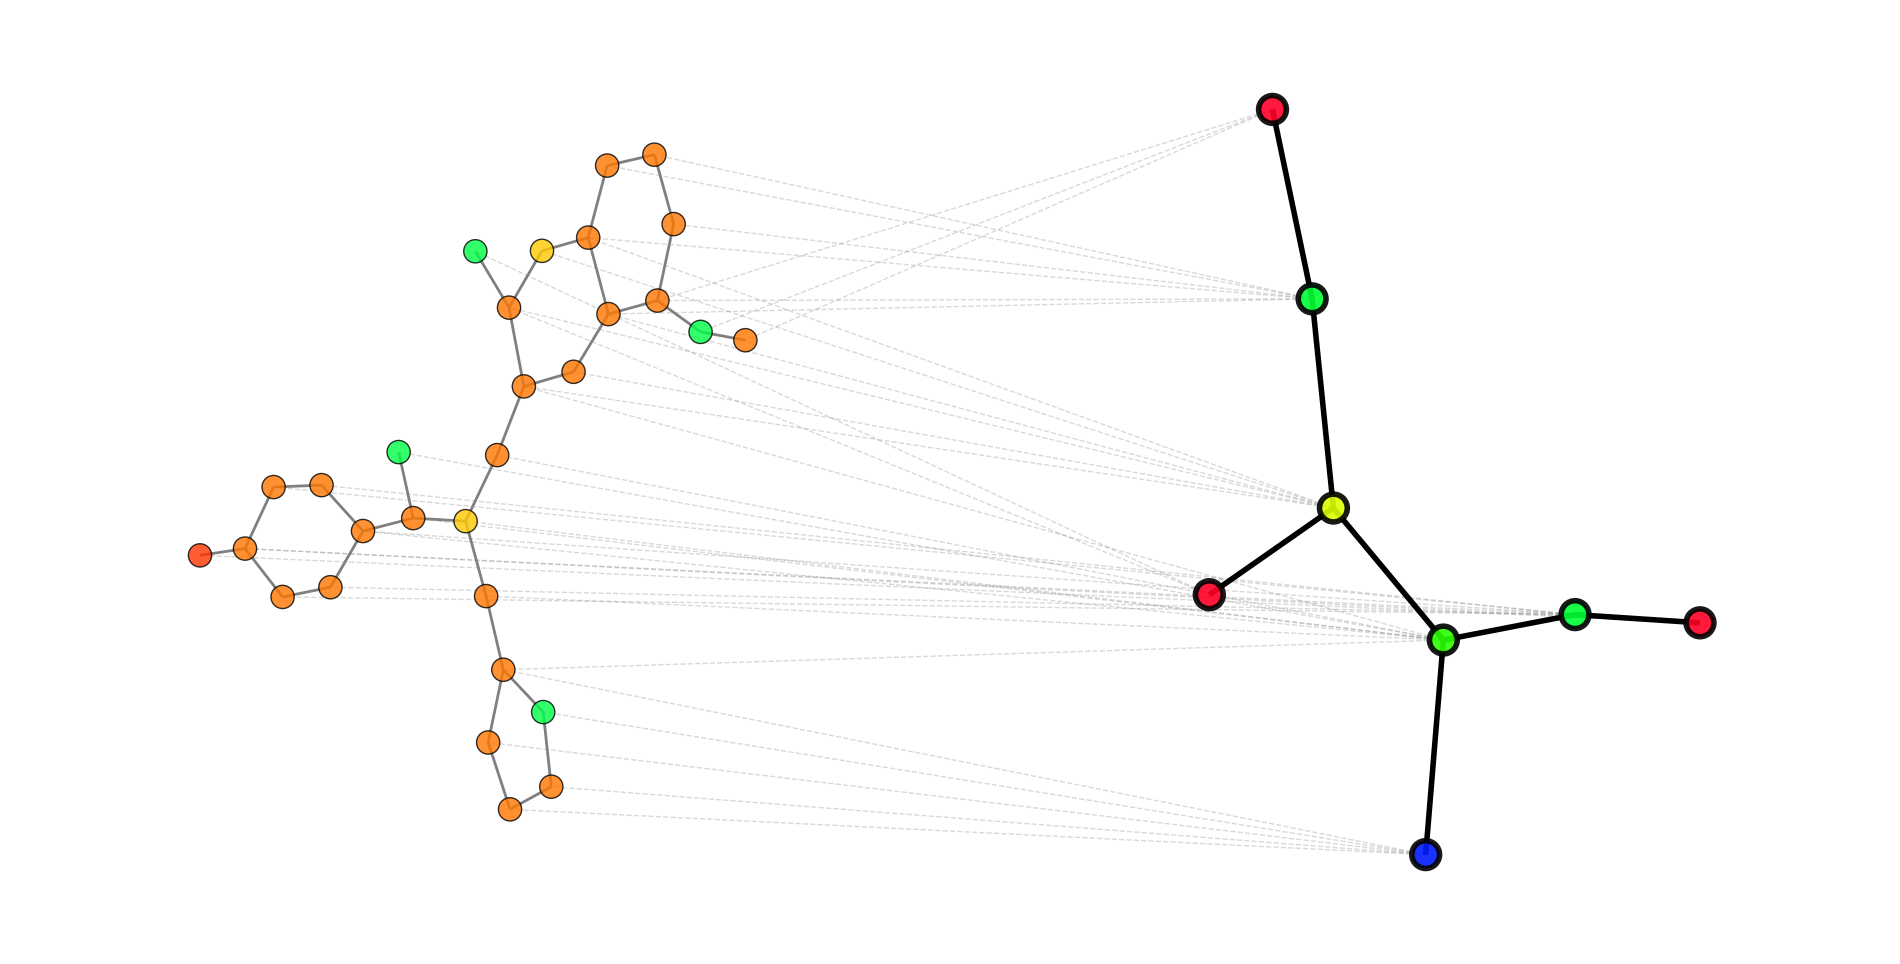

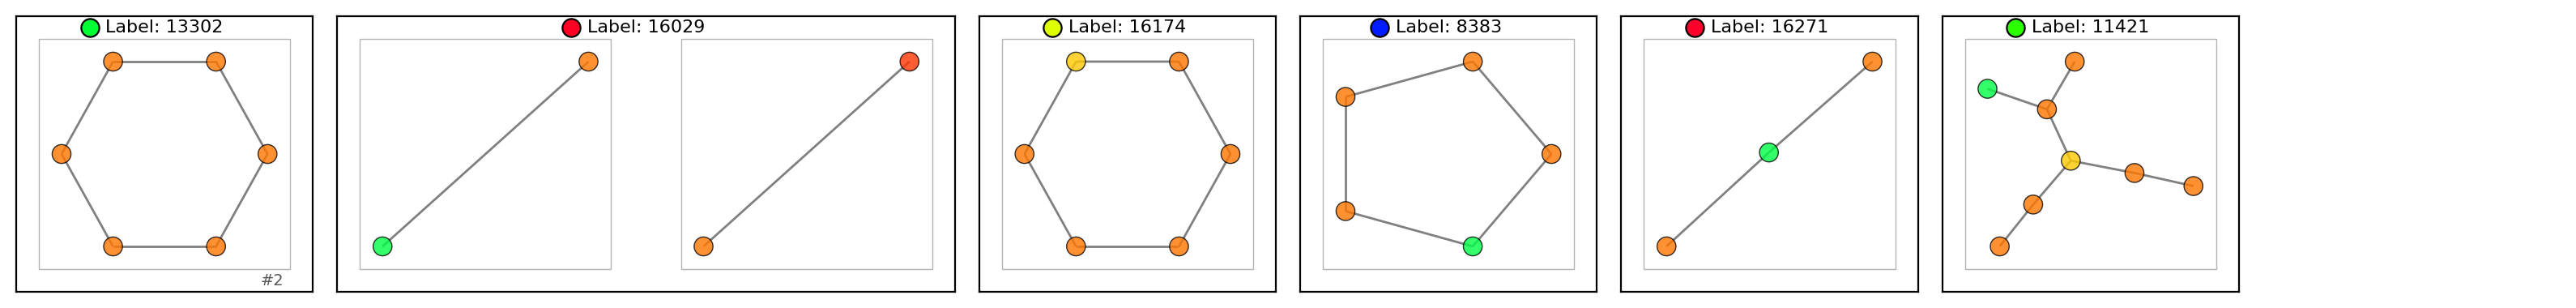

In [9]:
if not generated_graphs:
    print("No generated molecules to display.")
else:
    for sample_idx, (seed_idx,seed_graph,seed_interpretation_graph,generated_interpretation_graph,generated_instances,) in enumerate(zip(generator.last_successful_sampled_indices_,generator.last_seed_graphs_,generator.last_seed_interpretation_graphs_,generator.last_generated_interpretation_graphs_,generated_groups,)):
        print("=" * 120)
        print(f"sample {sample_idx} | seed index {seed_idx}")

        print("seed molecule")
        display_graphs([seed_graph], n_graphs_per_line=1)

        print("seed interpretation graph")
        display([seed_interpretation_graph], size=(5, 4))

        print("generated interpretation graph")
        display([generated_interpretation_graph], size=(5, 4))

        print(f"generated molecule instances ({len(generated_instances)})")
        display_graphs(generated_instances, n_graphs_per_line=n_instances_per_sample)
        for generated_instance in generated_instances:
            draw(generated_instance, decomposition_function=decomposition_function, nbits=nbits, label_mode=label_mode)
